<a href="https://colab.research.google.com/github/marcelo7bastos/relatorio_dados_damei/blob/main/notebooks/pronaf_ater_evolucao.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 **Evolução histórica dos dados**


*   Pronaf
*   Ater

  Periodo de análise: 2019 a 2026-mar



*Carregando os pacotes*

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
import pandas as pd
import os
import glob

# Dados Pronaf

In [3]:
import os
import glob
import pandas as pd

# Diretórios principais
RAW_DIR = '/content/drive/MyDrive/DAMEI_Relatorio_Dados/dados_brutos/dado_historico/PRONAF'
ARQUIVO_ATUAL = '/content/drive/MyDrive/DAMEI_Relatorio_Dados/dados_brutos/dado_atual/pronaf_gaia_20260414_teste.xlsx'
OUTPUT_DIR = '/content/drive/MyDrive/DAMEI_Relatorio_Dados/dados_brutos/saida_teste'

# Garante que a pasta de saída exista
os.makedirs(OUTPUT_DIR, exist_ok=True)

# 1. Carregar os dados históricos da pasta
excel_files = glob.glob(os.path.join(RAW_DIR, '*.xlsx'))
excel_files.sort()

print(f'Foram encontrados {len(excel_files)} arquivos:')

# Dicionário para armazenar os DataFrames
bases_pronaf = {}

try:
    for f in excel_files:
        nome_arquivo = os.path.basename(f)
        print(f'  • Carregando aba "Dados" de: {nome_arquivo}')
        # Carrega APENAS a aba 'Dados' de cada arquivo
        bases_pronaf[nome_arquivo] = pd.read_excel(f, sheet_name='Dados')

    print('\nConcluído! Todos os dados históricos foram carregados.')

    # 2. Carregar o arquivo específico com o dado atual
    nome_arquivo_atual = os.path.basename(ARQUIVO_ATUAL)
    print(f'\nCarregando a base atual: {nome_arquivo_atual}')
    bases_pronaf[nome_arquivo_atual] = pd.read_excel(ARQUIVO_ATUAL, sheet_name='Dados')
    print(f'\nSucesso! Total de {len(bases_pronaf)} arquivos carregados.')

except OSError as e:
    print(f'\n❌ Erro de Conexão: {e}')
    print('DICA: O Google Drive parece ter desconectado. Tente remontar o Drive ou reiniciar o ambiente de execução.')

Foram encontrados 11 arquivos:
  • Carregando aba "Dados" de: pronaf_gaia_historico_anual_2015.xlsx
  • Carregando aba "Dados" de: pronaf_gaia_historico_anual_2016.xlsx
  • Carregando aba "Dados" de: pronaf_gaia_historico_anual_2017.xlsx
  • Carregando aba "Dados" de: pronaf_gaia_historico_anual_2018.xlsx
  • Carregando aba "Dados" de: pronaf_gaia_historico_anual_2019.xlsx
  • Carregando aba "Dados" de: pronaf_gaia_historico_anual_2020.xlsx
  • Carregando aba "Dados" de: pronaf_gaia_historico_anual_2021.xlsx
  • Carregando aba "Dados" de: pronaf_gaia_historico_anual_2022.xlsx
  • Carregando aba "Dados" de: pronaf_gaia_historico_anual_2023.xlsx
  • Carregando aba "Dados" de: pronaf_gaia_historico_anual_2024.xlsx
  • Carregando aba "Dados" de: pronaf_gaia_historico_anual_2025.xlsx

Concluído! Todos os dados históricos foram carregados.

Carregando a base atual: pronaf_gaia_20260414_teste.xlsx

Sucesso! Total de 12 arquivos carregados.


In [4]:
#Comparando as colunas

arquivos_carregados = list(bases_pronaf.keys())
arquivo_referencia = arquivos_carregados[0]
colunas_referencia = set(bases_pronaf[arquivo_referencia].columns)

print(f"Usando '{arquivo_referencia}' como padrão ({len(colunas_referencia)} colunas).")
print("-" * 50)

todas_iguais = True

# Compara os demais arquivos com o arquivo de referência
for arquivo in arquivos_carregados[1:]:
    colunas_atuais = set(bases_pronaf[arquivo].columns)

    if colunas_referencia == colunas_atuais:
        print(f"✅ {arquivo} -> OK (Mesmas colunas)")
    else:
        todas_iguais = False
        print(f"❌ {arquivo} -> DIFERENÇA ENCONTRADA")

        # O que tem na referência mas falta neste arquivo
        colunas_faltando = colunas_referencia - colunas_atuais
        if colunas_faltando:
            print(f"    ⚠️ Faltando: {colunas_faltando}")

        # O que tem neste arquivo mas não tem na referência
        colunas_sobrando = colunas_atuais - colunas_referencia
        if colunas_sobrando:
            print(f"    ➕ Sobrando/A mais: {colunas_sobrando}")

print("-" * 50)
if todas_iguais:
    print("Sucesso! Todos os arquivos possuem exatamente as mesmas colunas. Estão prontos para serem unidos.")
else:
    print("Atenção: Foram encontradas diferenças nas colunas (veja o log acima).")

Usando 'pronaf_gaia_historico_anual_2015.xlsx' como padrão (19 colunas).
--------------------------------------------------
✅ pronaf_gaia_historico_anual_2016.xlsx -> OK (Mesmas colunas)
✅ pronaf_gaia_historico_anual_2017.xlsx -> OK (Mesmas colunas)
✅ pronaf_gaia_historico_anual_2018.xlsx -> OK (Mesmas colunas)
✅ pronaf_gaia_historico_anual_2019.xlsx -> OK (Mesmas colunas)
✅ pronaf_gaia_historico_anual_2020.xlsx -> OK (Mesmas colunas)
✅ pronaf_gaia_historico_anual_2021.xlsx -> OK (Mesmas colunas)
✅ pronaf_gaia_historico_anual_2022.xlsx -> OK (Mesmas colunas)
✅ pronaf_gaia_historico_anual_2023.xlsx -> OK (Mesmas colunas)
✅ pronaf_gaia_historico_anual_2024.xlsx -> OK (Mesmas colunas)
✅ pronaf_gaia_historico_anual_2025.xlsx -> OK (Mesmas colunas)
✅ pronaf_gaia_20260414_teste.xlsx -> OK (Mesmas colunas)
--------------------------------------------------
Sucesso! Todos os arquivos possuem exatamente as mesmas colunas. Estão prontos para serem unidos.


In [5]:
#Agrupando todas as tabelas em um único dataframa
#Lista para guardar os DataFrames temporários
lista_dfs = []

# Percorre o dicionário adicionando a coluna de origem
for nome_arquivo, df in bases_pronaf.items():
    df_temp = df.copy() # Cria uma cópia para não alterar o dicionário original
    df_temp['arquivo_origem'] = nome_arquivo # Adiciona a rastreabilidade
    lista_dfs.append(df_temp)

# Junta (empilha) todos os DataFrames em um único
df_pronaf_consolidado = pd.concat(lista_dfs, ignore_index=True)

print("✅ Bases consolidadas com sucesso!")
print(f"Total de linhas: {df_pronaf_consolidado.shape[0]}")
print(f"Total de colunas: {df_pronaf_consolidado.shape[1]}")
print("-" * 50)

# Mostra as 5 primeiras linhas para você inspecionar visualmente
display(df_pronaf_consolidado.head())

✅ Bases consolidadas com sucesso!
Total de linhas: 63868
Total de colunas: 20
--------------------------------------------------


,dt_referencia,dt_geracao,ANO,nome_municipio,uf,cod_ibge_municipio,cod_ibge_uf,qtd_contratos_anual_Feminino,qtd_contratos_anual_Masculino,qtd_contratos_anual_Sem_Identificacao,valor_total_contratos_anual_Feminino,valor_total_contratos_anual_Masculino,valor_total_contratos_anual_Sem_Identificacao,qtd_operacoes_anual_Feminino,qtd_operacoes_anual_Masculino,qtd_operacoes_anual_Sem_Identificacao,ticket_medio_anual_Feminino,ticket_medio_anual_Masculino,ticket_medio_anual_Sem_Identificacao,arquivo_origem
0,2015_12,2026_04_29,2015,Acrelândia,AC,1200013,12,79,260,0,1809742.00,7032661.40,0.0,79,260,0,22908.126582,27048.697692,0.0,pronaf_gaia_historico_anual_2015.xlsx
1,2015_12,2026_04_29,2015,Assis Brasil,AC,1200054,12,3,0,0,51998.85,0.00,0.0,3,0,0,17332.950000,0.000000,0.0,pronaf_gaia_historico_anual_2015.xlsx
2,2015_12,2026_04_29,2015,Brasiléia,AC,1200104,12,45,89,0,889395.49,2660606.24,0.0,45,89,0,19764.344222,29894.452135,0.0,pronaf_gaia_historico_anual_2015.xlsx
3,2015_12,2026_04_29,2015,Bujari,AC,1200138,12,8,29,0,315031.28,788523.79,0.0,8,29,0,39378.910000,27190.475517,0.0,pronaf_gaia_historico_anual_2015.xlsx
4,2015_12,2026_04_29,2015,Capixaba,AC,1200179,12,14,8,0,349557.39,136963.52,0.0,14,8,0,24968.385000,17120.440000,0.0,pronaf_gaia_historico_anual_2015.xlsx


In [6]:
df_pronaf_consolidado.columns.tolist()

['dt_referencia',
 'dt_geracao',
 'ANO',
 'nome_municipio',
 'uf',
 'cod_ibge_municipio',
 'cod_ibge_uf',
 'qtd_contratos_anual_Feminino',
 'qtd_contratos_anual_Masculino',
 'qtd_contratos_anual_Sem_Identificacao',
 'valor_total_contratos_anual_Feminino',
 'valor_total_contratos_anual_Masculino',
 'valor_total_contratos_anual_Sem_Identificacao',
 'qtd_operacoes_anual_Feminino',
 'qtd_operacoes_anual_Masculino',
 'qtd_operacoes_anual_Sem_Identificacao',
 'ticket_medio_anual_Feminino',
 'ticket_medio_anual_Masculino',
 'ticket_medio_anual_Sem_Identificacao',
 'arquivo_origem']

In [7]:
#Tratamento dos dados


# 1. Definir as listas de colunas
colunas_texto = [
    'dt_referencia', 'dt_geracao', 'ANO', 'nome_municipio',
    'uf', 'cod_ibge_municipio', 'cod_ibge_uf', 'arquivo_origem'
]

colunas_numero = [
    'qtd_contratos_anual_Feminino', 'qtd_contratos_anual_Masculino', 'qtd_contratos_anual_Sem_Identificacao',
    'valor_total_contratos_anual_Feminino', 'valor_total_contratos_anual_Masculino', 'valor_total_contratos_anual_Sem_Identificacao',
    'qtd_operacoes_anual_Feminino', 'qtd_operacoes_anual_Masculino', 'qtd_operacoes_anual_Sem_Identificacao',
    'ticket_medio_anual_Feminino', 'ticket_medio_anual_Masculino', 'ticket_medio_anual_Sem_Identificacao'
]

print("A iniciar o tratamento dos dados...")

# 2. Tratamento das colunas de texto (Converter para texto e remover espaços)
for col in colunas_texto:
    if col in df_pronaf_consolidado.columns:
        # Converte para string e remove espaços em branco nas extremidades (strip)
        df_pronaf_consolidado[col] = df_pronaf_consolidado[col].astype(str).str.strip()

        # Nota: Caso queira remover *absolutamente todos* os espaços (mesmo entre as palavras),
        # substitua a linha acima por:
        # df_pronaf_consolidado[col] = df_pronaf_consolidado[col].astype(str).str.replace(' ', '', regex=False)

# 3. Tratamento das colunas numéricas (Definir como número)
for col in colunas_numero:
    if col in df_pronaf_consolidado.columns:
        # pd.to_numeric converte de forma segura.
        # errors='coerce' transforma eventuais textos com erro (ex: '-') em valores nulos (NaN), permitindo fazer contas depois
        df_pronaf_consolidado[col] = pd.to_numeric(df_pronaf_consolidado[col], errors='coerce')

print("Tratamento concluído com sucesso!\n")
print("-" * 50)
print("Resumo dos tipos de dados atualizados:")
# Exibe um resumo para confirmar se os tipos estão corretos (object/string e float/int)
print(df_pronaf_consolidado[colunas_texto + colunas_numero].dtypes)

A iniciar o tratamento dos dados...
Tratamento concluído com sucesso!

--------------------------------------------------
Resumo dos tipos de dados atualizados:
dt_referencia                                     object
dt_geracao                                        object
ANO                                               object
nome_municipio                                    object
uf                                                object
cod_ibge_municipio                                object
cod_ibge_uf                                       object
arquivo_origem                                    object
qtd_contratos_anual_Feminino                       int64
qtd_contratos_anual_Masculino                      int64
qtd_contratos_anual_Sem_Identificacao              int64
valor_total_contratos_anual_Feminino             float64
valor_total_contratos_anual_Masculino            float64
valor_total_contratos_anual_Sem_Identificacao    float64
qtd_operacoes_anual_Feminino             

Teste de graficos

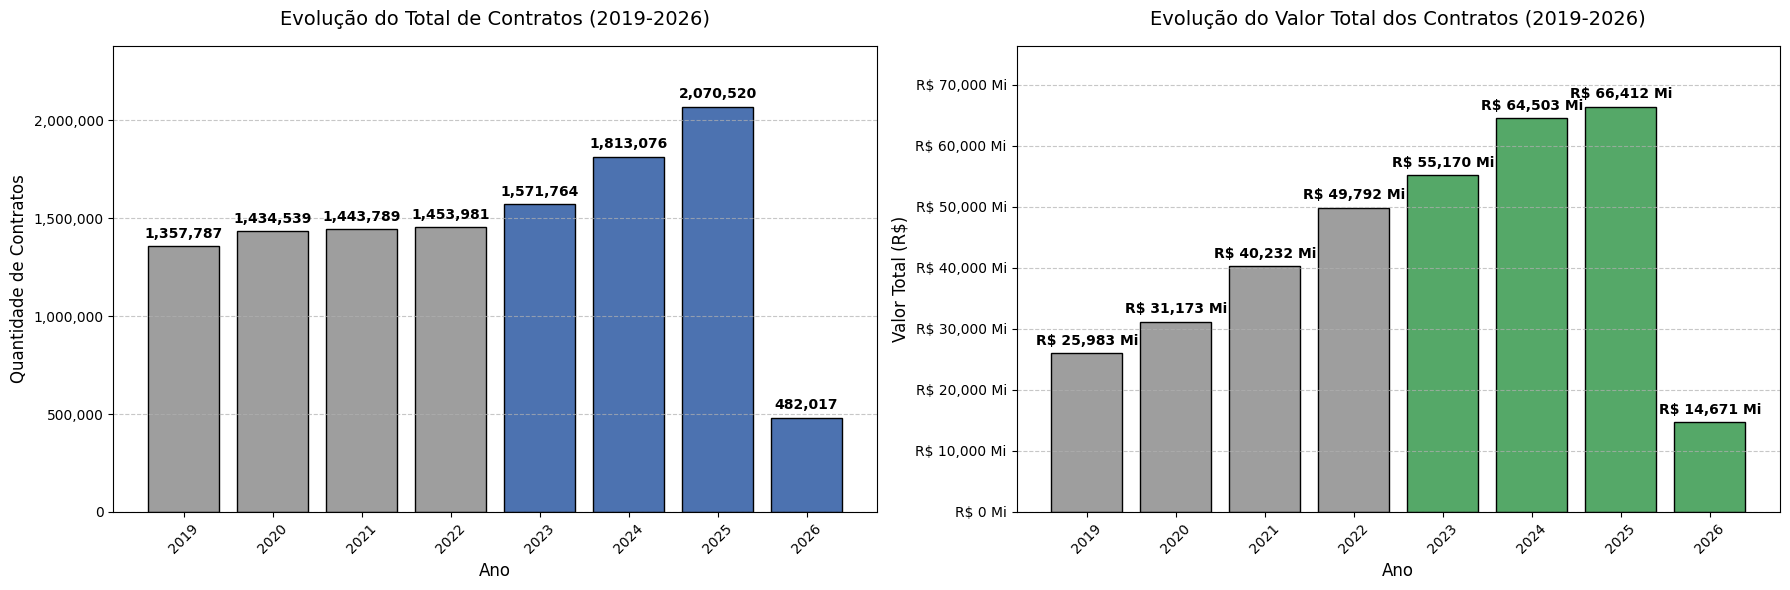

In [8]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd

# 1. Criar colunas de Totais Globais
df_pronaf_consolidado['qtd_contratos_total'] = (
    df_pronaf_consolidado['qtd_contratos_anual_Feminino'].fillna(0) +
    df_pronaf_consolidado['qtd_contratos_anual_Masculino'].fillna(0) +
    df_pronaf_consolidado['qtd_contratos_anual_Sem_Identificacao'].fillna(0)
)

df_pronaf_consolidado['valor_contratos_total'] = (
    df_pronaf_consolidado['valor_total_contratos_anual_Feminino'].fillna(0) +
    df_pronaf_consolidado['valor_total_contratos_anual_Masculino'].fillna(0) +
    df_pronaf_consolidado['valor_total_contratos_anual_Sem_Identificacao'].fillna(0)
)

# 2. FILTRAR OS ANOS DE 2019 A 2026
# Converte a coluna ANO para numérico para facilitar o filtro matemático
df_pronaf_consolidado['ANO_num'] = pd.to_numeric(df_pronaf_consolidado['ANO'], errors='coerce')

# Aplica o filtro desejado
df_filtrado = df_pronaf_consolidado[
    (df_pronaf_consolidado['ANO_num'] >= 2019) &
    (df_pronaf_consolidado['ANO_num'] <= 2026)
].copy()

# 3. Agrupar os dados por Ano (usando a base filtrada)
df_evolucao = df_filtrado.groupby('ANO_num')[['qtd_contratos_total', 'valor_contratos_total']].sum().reset_index()

# Garantir que o ano fique sem casas decimais (ex: 2019 em vez de 2019.0) e ordenado
df_evolucao['ANO_num'] = df_evolucao['ANO_num'].astype(int)
df_evolucao = df_evolucao.sort_values('ANO_num')

# 4. Definir cores dinâmicas
# Cria uma lista de cores: Cinza para anos <= 2022, e as cores originais para os mais recentes
cores_qtd = ['#9E9E9E' if ano <= 2022 else '#4C72B0' for ano in df_evolucao['ANO_num']]
cores_valor = ['#9E9E9E' if ano <= 2022 else '#55A868' for ano in df_evolucao['ANO_num']]

# 5. Desenhar os Gráficos
# Apenas UMA chamada para criar a figura com 2 gráficos lado a lado
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

## ----- Gráficos -------

# --- Gráfico 1: Quantidade de Contratos ---
# Passamos a lista 'cores_qtd' e guardamos as barras na variável 'barras_qtd'
barras_qtd = ax1.bar(df_evolucao['ANO_num'].astype(str), df_evolucao['qtd_contratos_total'], color=cores_qtd, edgecolor='black')
ax1.set_title('Evolução do Total de Contratos (2019-2026)', fontsize=14, pad=15)
ax1.set_xlabel('Ano', fontsize=12)
ax1.set_ylabel('Quantidade de Contratos', fontsize=12)
ax1.tick_params(axis='x', rotation=45)
ax1.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# Adicionar o valor no topo de cada barra (Quantidade)
for barra in barras_qtd:
    altura = barra.get_height()
    ax1.annotate(f'{int(altura):,}', # Formata com separador de milhar
                 xy=(barra.get_x() + barra.get_width() / 2, altura),
                 xytext=(0, 4),  # Desloca o texto 4 pontos para cima
                 textcoords="offset points",
                 ha='center', va='bottom', fontsize=10, fontweight='bold')

# --- Gráfico 2: Valor Total dos Contratos ---
# Passamos a lista 'cores_valor' e guardamos as barras na variável 'barras_valor'
barras_valor = ax2.bar(df_evolucao['ANO_num'].astype(str), df_evolucao['valor_contratos_total'], color=cores_valor, edgecolor='black')
ax2.set_title('Evolução do Valor Total dos Contratos (2019-2026)', fontsize=14, pad=15)
ax2.set_xlabel('Ano', fontsize=12)
ax2.set_ylabel('Valor Total (R$)', fontsize=12)
ax2.tick_params(axis='x', rotation=45)
ax2.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f'R$ {x/1e6:,.0f} Mi'))
ax2.grid(axis='y', linestyle='--', alpha=0.7)

# Adicionar o valor no topo de cada barra (Valor)
for barra in barras_valor:
    altura = barra.get_height()
    # Formata em milhões para não poluir visualmente (ex: R$ 150 Mi)
    rotulo = f'R$ {altura/1e6:,.0f} Mi'
    ax2.annotate(rotulo,
                 xy=(barra.get_x() + barra.get_width() / 2, altura),
                 xytext=(0, 4),
                 textcoords="offset points",
                 ha='center', va='bottom', fontsize=10, fontweight='bold')

# Aumentar um pouco o limite do eixo Y para o texto não encostar no teto do gráfico
ax1.set_ylim(0, df_evolucao['qtd_contratos_total'].max() * 1.15)
ax2.set_ylim(0, df_evolucao['valor_contratos_total'].max() * 1.15)

plt.tight_layout()
plt.show()

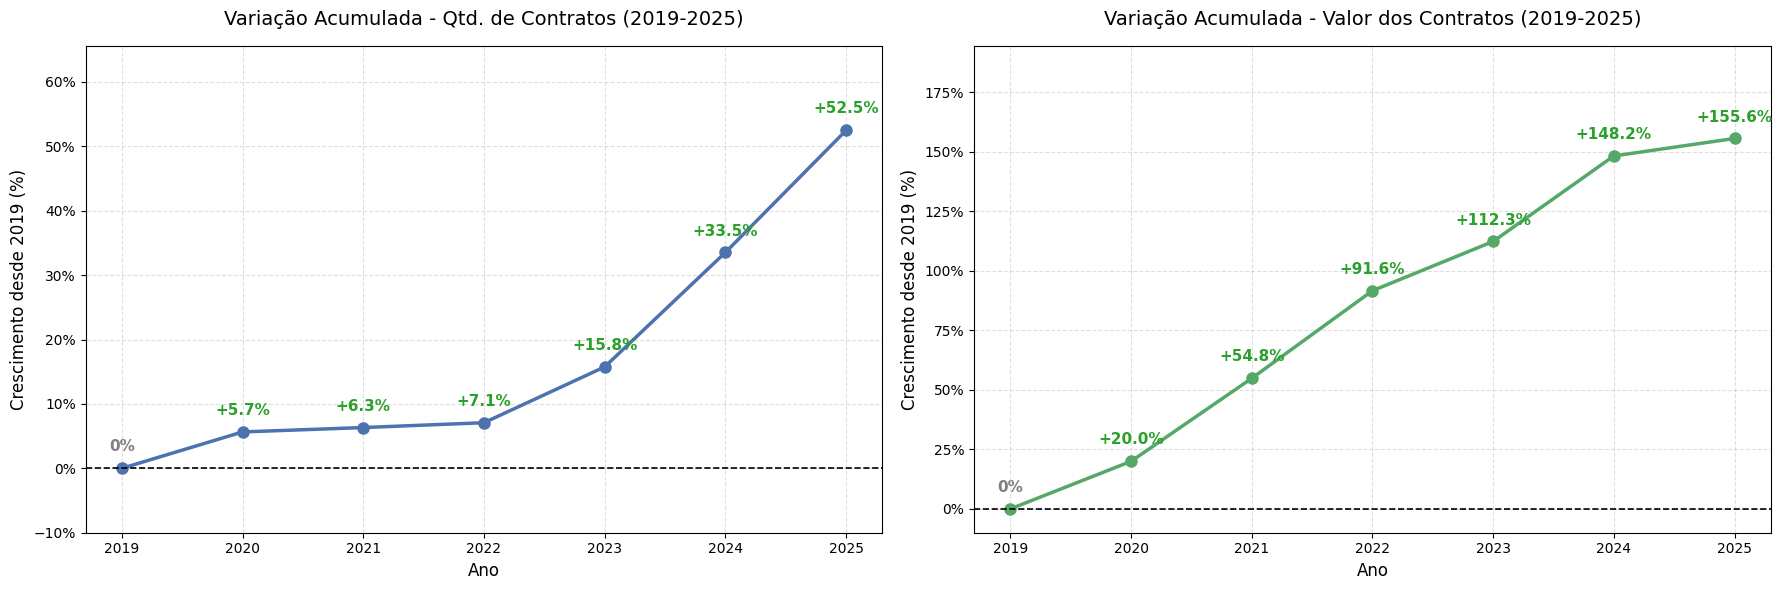

In [9]:
# Gráfico de variação acumulada

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd

# 1. Aplicar o filtro estrito (2019 a 2025) e agrupar
df_filtrado_25 = df_pronaf_consolidado[
    (df_pronaf_consolidado['ANO_num'] >= 2019) &
    (df_pronaf_consolidado['ANO_num'] <= 2025)
].copy()

df_evolucao_25 = df_filtrado_25.groupby('ANO_num')[['qtd_contratos_total', 'valor_contratos_total']].sum().reset_index()
df_evolucao_25['ANO_num'] = df_evolucao_25['ANO_num'].astype(int)
df_evolucao_25 = df_evolucao_25.sort_values('ANO_num')

# 2. Calcular a variação ACUMULADA em relação ao ano-base (2019)
base_qtd = df_evolucao_25.loc[df_evolucao_25['ANO_num'] == 2019, 'qtd_contratos_total'].values[0]
base_valor = df_evolucao_25.loc[df_evolucao_25['ANO_num'] == 2019, 'valor_contratos_total'].values[0]

# Fórmula da variação acumulada: ((Valor_do_Ano / Valor_da_Base) - 1) * 100
df_evolucao_25['var_acum_qtd'] = ((df_evolucao_25['qtd_contratos_total'] / base_qtd) - 1) * 100
df_evolucao_25['var_acum_valor'] = ((df_evolucao_25['valor_contratos_total'] / base_valor) - 1) * 100

# 3. Desenhar os Gráficos
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

## ----- Gráfico 1: Variação Acumulada da Quantidade -------
ax1.plot(df_evolucao_25['ANO_num'].astype(str), df_evolucao_25['var_acum_qtd'], color='#4C72B0', marker='o', linewidth=2.5, markersize=8)
ax1.set_title('Variação Acumulada - Qtd. de Contratos (2019-2025)', fontsize=14, pad=15)
ax1.set_xlabel('Ano', fontsize=12)
ax1.set_ylabel('Crescimento desde 2019 (%)', fontsize=12)
ax1.axhline(0, color='black', linewidth=1.2, linestyle='--')
ax1.grid(axis='both', linestyle='--', alpha=0.4)
ax1.yaxis.set_major_formatter(ticker.PercentFormatter(decimals=0))

# Adicionar os rótulos de dados
for x, y in zip(df_evolucao_25['ANO_num'].astype(str), df_evolucao_25['var_acum_qtd']):
    deslocamento = 10 if y >= 0 else -18
    alinhamento_v = 'bottom' if y >= 0 else 'top'
    cor_texto = '#2CA02C' if y > 0 else ('#D62728' if y < 0 else '#7F7F7F')
    texto = '0%' if x == '2019' else f'{y:+.1f}%'
    ax1.annotate(texto, xy=(x, y), xytext=(0, deslocamento), textcoords="offset points", ha='center', va=alinhamento_v, fontsize=11, fontweight='bold', color=cor_texto)

## ----- Gráfico 2: Variação Acumulada do Valor -------
ax2.plot(df_evolucao_25['ANO_num'].astype(str), df_evolucao_25['var_acum_valor'], color='#55A868', marker='o', linewidth=2.5, markersize=8)
ax2.set_title('Variação Acumulada - Valor dos Contratos (2019-2025)', fontsize=14, pad=15)
ax2.set_xlabel('Ano', fontsize=12)
ax2.set_ylabel('Crescimento desde 2019 (%)', fontsize=12)
ax2.axhline(0, color='black', linewidth=1.2, linestyle='--')
ax2.grid(axis='both', linestyle='--', alpha=0.4)
ax2.yaxis.set_major_formatter(ticker.PercentFormatter(decimals=0))

# Adicionar os rótulos de dados
for x, y in zip(df_evolucao_25['ANO_num'].astype(str), df_evolucao_25['var_acum_valor']):
    deslocamento = 10 if y >= 0 else -18
    alinhamento_v = 'bottom' if y >= 0 else 'top'
    cor_texto = '#2CA02C' if y > 0 else ('#D62728' if y < 0 else '#7F7F7F')
    texto = '0%' if x == '2019' else f'{y:+.1f}%'
    ax2.annotate(texto, xy=(x, y), xytext=(0, deslocamento), textcoords="offset points", ha='center', va=alinhamento_v, fontsize=11, fontweight='bold', color=cor_texto)

y_min_qtd = df_evolucao_25['var_acum_qtd'].min()
ax1.set_ylim(y_min_qtd * 1.35 if y_min_qtd < 0 else -10, df_evolucao_25['var_acum_qtd'].max() * 1.25)

y_min_valor = df_evolucao_25['var_acum_valor'].min()
ax2.set_ylim(y_min_valor * 1.35 if y_min_valor < 0 else -10, df_evolucao_25['var_acum_valor'].max() * 1.25)

plt.tight_layout()
plt.show()

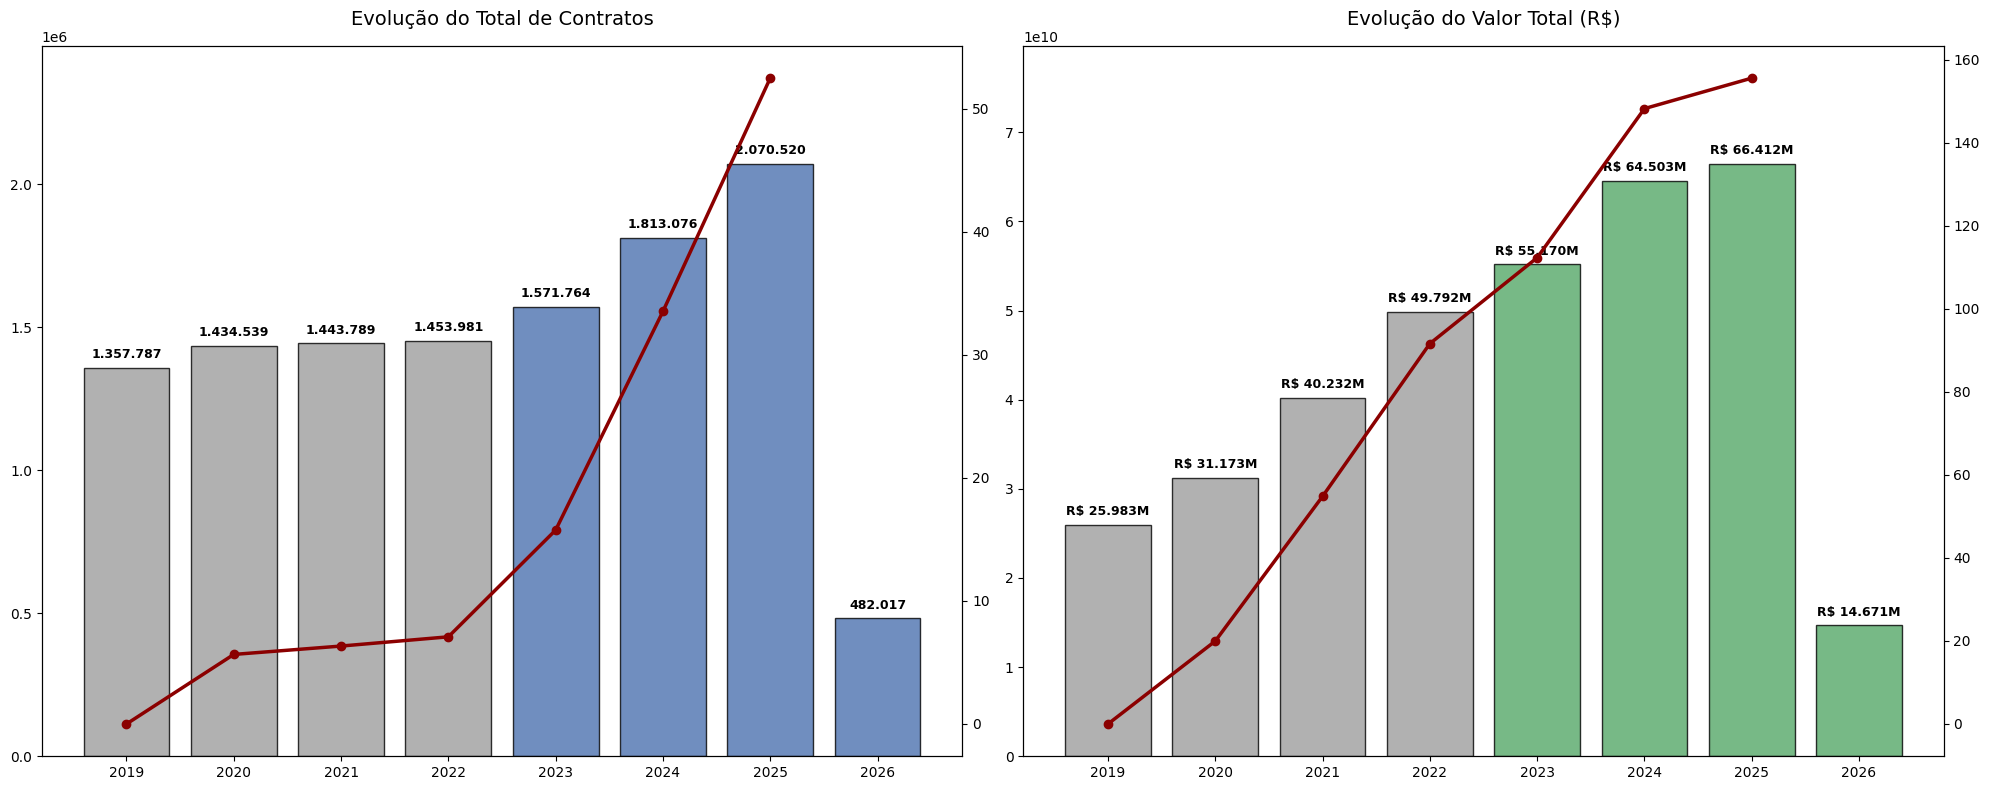

In [10]:
# Gráfico: Evolução do Pronaf com Rótulos
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd
import os

# 1. Preparar dados
df_pronaf_consolidado['ANO_num'] = pd.to_numeric(df_pronaf_consolidado['ANO'], errors='coerce')
df_filtrado_plot = df_pronaf_consolidado[(df_pronaf_consolidado['ANO_num'] >= 2019) & (df_pronaf_consolidado['ANO_num'] <= 2026)].copy()
df_evolucao_plot = df_filtrado_plot.groupby('ANO_num')[['qtd_contratos_total', 'valor_contratos_total']].sum().reset_index()
df_evolucao_plot['ANO_num'] = df_evolucao_plot['ANO_num'].astype(int)
df_evolucao_plot = df_evolucao_plot.sort_values('ANO_num')

base_qtd = df_evolucao_plot.loc[df_evolucao_plot['ANO_num'] == 2019, 'qtd_contratos_total'].values[0]
base_valor = df_evolucao_plot.loc[df_evolucao_plot['ANO_num'] == 2019, 'valor_contratos_total'].values[0]
df_evolucao_plot['var_acum_qtd'] = ((df_evolucao_plot['qtd_contratos_total'] / base_qtd) - 1) * 100
df_evolucao_plot['var_acum_valor'] = ((df_evolucao_plot['valor_contratos_total'] / base_valor) - 1) * 100
df_linhas = df_evolucao_plot[df_evolucao_plot['ANO_num'] <= 2025].copy()

cores_qtd = ['#9E9E9E' if ano <= 2022 else '#4C72B0' for ano in df_evolucao_plot['ANO_num']]
cores_valor = ['#9E9E9E' if ano <= 2022 else '#55A868' for ano in df_evolucao_plot['ANO_num']]

# 2. Desenhar e SALVAR
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# Gráfico 1 - Qtd
barras1 = ax1.bar(df_evolucao_plot['ANO_num'].astype(str), df_evolucao_plot['qtd_contratos_total'], color=cores_qtd, alpha=0.8, edgecolor='black')
ax1_twin = ax1.twinx()
ax1_twin.plot(df_linhas['ANO_num'].astype(str), df_linhas['var_acum_qtd'], color='darkred', marker='o', linewidth=2.5)
ax1.set_title('Evolução do Total de Contratos', fontsize=14, pad=15)

for barra in barras1:
    altura = barra.get_height()
    ax1.annotate(f'{int(altura):,}'.replace(',', '.'), xy=(barra.get_x() + barra.get_width() / 2, altura),
                 xytext=(0, 5), textcoords="offset points", ha='center', va='bottom', fontsize=9, fontweight='bold')

# Gráfico 2 - Valor
barras2 = ax2.bar(df_evolucao_plot['ANO_num'].astype(str), df_evolucao_plot['valor_contratos_total'], color=cores_valor, alpha=0.8, edgecolor='black')
ax2_twin = ax2.twinx()
ax2_twin.plot(df_linhas['ANO_num'].astype(str), df_linhas['var_acum_valor'], color='darkred', marker='o', linewidth=2.5)
ax2.set_title('Evolução do Valor Total (R$)', fontsize=14, pad=15)

for barra in barras2:
    altura = barra.get_height()
    ax2.annotate(f'R$ {altura/1e6:,.0f}M'.replace(',', '.'), xy=(barra.get_x() + barra.get_width() / 2, altura),
                 xytext=(0, 5), textcoords="offset points", ha='center', va='bottom', fontsize=9, fontweight='bold')

ax1.set_ylim(0, df_evolucao_plot['qtd_contratos_total'].max() * 1.2)
ax2.set_ylim(0, df_evolucao_plot['valor_contratos_total'].max() * 1.2)
plt.tight_layout()
plt.savefig('temp_evolucao.png', dpi=300)
plt.show()

In [13]:
ax1.set_ylim(0, df_evolucao_plot['qtd_contratos_total'].max() * 1.2)
ax2.set_ylim(0, df_evolucao_plot['valor_contratos_total'].max() * 1.2)
plt.tight_layout()
plt.savefig('temp_evolucao.png', dpi=300)
plt.show()

<Figure size 640x480 with 0 Axes>

In [14]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [15]:
# Ranking dos Municípios
import pandas as pd

# 1. Definir os anos de comparação
ano_base = 2023
ano_final = 2025

# 2. Agrupar os dados por Município, UF e Ano
df_mun = df_pronaf_consolidado.groupby(['nome_municipio', 'uf', 'ANO_num'])[['valor_contratos_total', 'qtd_contratos_total']].sum().reset_index()

# 3. Filtrar apenas os dois anos que queremos comparar
df_mun_comp = df_mun[df_mun['ANO_num'].isin([ano_base, ano_final])]

# 4. Pivotar a tabela (Garante que se um ano não existe, ele vire 0)
df_pivot = df_mun_comp.pivot_table(
    index=['nome_municipio', 'uf'],
    columns='ANO_num',
    values=['valor_contratos_total', 'qtd_contratos_total'],
    fill_value=0
)

# Ajustar nomes das colunas
df_pivot.columns = [f'{metrica}_{ano}' for metrica, ano in df_pivot.columns]
df_pivot = df_pivot.reset_index()

# Definir as colunas geradas
col_valor_base = f'valor_contratos_total_{ano_base}'
col_valor_final = f'valor_contratos_total_{ano_final}'
col_qtd_base = f'qtd_contratos_total_{ano_base}'
col_qtd_final = f'qtd_contratos_total_{ano_final}'

# 5. Aplicar filtros de consistência APENAS no ano base
# Isso garante que se o município sumiu em 2025, ele apareça como queda de 100%
df_pivot = df_pivot[df_pivot[col_valor_base] >= 100000].copy()
df_pivot = df_pivot[df_pivot[col_qtd_base] >= 5].copy()

# 6. Calcular a variação percentual
# Usamos um preenchimento para evitar divisão por zero se o ano base for zero (embora o filtro acima já previna)
df_pivot['var_pct_valor'] = ((df_pivot[col_valor_final] / df_pivot[col_valor_base]) - 1) * 100
df_pivot['var_pct_qtd'] = ((df_pivot[col_qtd_final] / df_pivot[col_qtd_base]) - 1) * 100

# 7. Separar os 3 Maiores e 3 Menores
top_3_maiores = df_pivot.sort_values(by='var_pct_valor', ascending=False).head(3)
top_3_menores = df_pivot.sort_values(by='var_pct_valor', ascending=True).head(3)

print(f"✅ Rankings atualizados para {ano_base} vs {ano_final}.")
print(f"Total de municípios qualificados no Brasil: {len(df_pivot)}")

✅ Rankings atualizados para 2023 vs 2025.
Total de municípios qualificados no Brasil: 4950


In [16]:
import pandas as pd
import numpy as np

def calcular_rankings_aprimorado(df, ano_ini=2023, ano_fim=2025):
    """
    Calcula rankings de variação com tratamento de nulos e critérios de relevância.
    """
    # Agrupamento base
    df_agrupado = df.groupby(['nome_municipio', 'uf', 'ANO_num'])[['valor_contratos_total', 'qtd_contratos_total']].sum().reset_index()

    # Pivotagem para comparação direta
    df_p = df_agrupado[df_agrupado['ANO_num'].isin([ano_ini, ano_fim])].pivot_table(
        index=['nome_municipio', 'uf'],
        columns='ANO_num',
        values=['valor_contratos_total', 'qtd_contratos_total'],
        fill_value=0
    )

    # Flatten colunas
    df_p.columns = [f'{c[0]}_{int(c[1])}' for c in df_p.columns]
    df_p = df_p.reset_index()

    # Colunas dinâmicas
    v_ini, v_fim = f'valor_contratos_total_{ano_ini}', f'valor_contratos_total_{ano_fim}'
    q_ini, q_fim = f'qtd_contratos_total_{ano_ini}', f'qtd_contratos_total_{ano_fim}'

    # Cálculo de Variação (com tratamento para divisão por zero)
    df_p['var_pct_valor'] = np.where(df_p[v_ini] > 0, ((df_p[v_fim] / df_p[v_ini]) - 1) * 100, 0)
    df_p['var_pct_qtd'] = np.where(df_p[q_ini] > 0, ((df_p[q_fim] / df_p[q_ini]) - 1) * 100, 0)

    # Filtro de relevância: Mínimo de 50k ou 3 contratos no ano base
    df_relevante = df_p[(df_p[v_ini] >= 50000) | (df_p[q_ini] >= 3)].copy()

    return df_relevante

# Execução
df_pivot = calcular_rankings_aprimorado(df_pronaf_consolidado)
top_3_maiores = df_pivot.sort_values('var_pct_valor', ascending=False).head(3)
print(f"Rankings recalculados. Municípios processados: {len(df_pivot)}")

Rankings recalculados. Municípios processados: 5272


In [17]:
def gerar_insight_ia_robusto(dados_df):
    import google.generativeai as genai
    import time

    modelos_para_testar = ['gemini-1.5-flash', 'gemini-1.5-pro', 'gemini-pro']
    texto_tabela = dados_df.to_markdown(index=False)

    prompt = f"Analise estes top 3 crescimentos do PRONAF (2023-2025):\n{texto_tabela}\nForneça um insight executivo curto (2 parágrafos)."

    for modelo_nome in modelos_para_testar:
        try:
            print(f"Tentando modelo: {modelo_nome}...")
            model = genai.GenerativeModel(modelo_nome)
            # Retry loop para 429
            for i in range(3):
                try:
                    response = model.generate_content(prompt)
                    return response.text
                except Exception as e:
                    if "429" in str(e):
                        time.sleep(20)
                        continue
                    raise e
        except Exception as e:
            print(f"Falha no modelo {modelo_nome}: {e}")
            continue
    return "Não foi possível gerar insight no momento devido a limites de cota."

# Exemplo de uso
# insight = gerar_insight_ia_robusto(top_3_maiores)
# print(insight)

In [18]:
import pandas as pd

# --- INVESTIGAÇÃO DE DADOS POR UF ---
# Substitua 'TO' pela UF que está vindo 'Sem Informação'
uf_para_investigar = 'AC'

print(f'Analisando dados brutos para: {uf_para_investigar}')

# 1. Verificar se existem dados para os anos de comparação
dados_uf_base = df_mun[(df_mun['uf'] == uf_para_investigar) & (df_mun['ANO_num'] == 2023)]
dados_uf_final = df_mun[(df_mun['uf'] == uf_para_investigar) & (df_mun['ANO_num'] == 2025)]

print(f'Linhas encontradas em 2023: {len(dados_uf_base)}')
print(f'Linhas encontradas em 2025: {len(dados_uf_final)}')

# 2. Verificar quantos passariam pelo filtro de R$ 100k e 5 contratos
if not dados_uf_base.empty:
    aptos = dados_uf_base[(dados_uf_base['valor_contratos_total'] >= 100000) & (dados_uf_base['qtd_contratos_total'] >= 5)]
    print(f'Municípios que atendem ao critério mínimo (R$ 100k + 5 contratos) em 2023: {len(aptos)}')

    if len(aptos) == 0:
        print('\n👉 Sugestão: Reduzir os limites na célula Q6HwWnW7N2Cp (ex: para R$ 10.000 e 1 contrato) para esta UF.')
    else:
        display(aptos.head())
else:
    print('❌ Não foram encontrados dados para esta UF no ano base.')

Analisando dados brutos para: AC
Linhas encontradas em 2023: 23
Linhas encontradas em 2025: 23
Municípios que atendem ao critério mínimo (R$ 100k + 5 contratos) em 2023: 21


,nome_municipio,uf,ANO_num,valor_contratos_total,qtd_contratos_total
303,Acrelândia,AC,2023,28357110.48,329
4269,Assis Brasil,AC,2023,2855321.16,36
8144,Brasiléia,AC,2023,31008170.35,321
8659,Bujari,AC,2023,23178305.25,362
11738,Capixaba,AC,2023,3075991.63,37


In [19]:
import pandas as pd

# --- DIAGNÓSTICO DE MUNICÍPIOS COM PROBLEMAS ---
# Filtramos municípios que resultaram em 0 no ano final ou que sumiram do ranking

print("🔍 Investigando municípios com possíveis inconsistências (2023 vs 2025):")

# 1. Localizar municípios que tinham dados em 2023 mas estão zerados em 2025 no pivot
problemas_queda = df_pivot[(df_pivot[col_valor_base] > 0) & (df_pivot[col_valor_final] == 0)].copy()

# 2. Localizar municípios com variações suspeitas (ex: crescimentos acima de 1000%)
problemas_salto = df_pivot[df_pivot['var_pct_valor'] > 1000].copy()

print(f"\n• Municípios com queda de 100% (Zerados em 2025): {len(problemas_queda)}")
print(f"• Municípios com crescimento > 1000%: {len(problemas_salto)}")

if not problemas_queda.empty:
    print("\nExemplos de municípios 'Zerados' em 2025 (Top 5):")
    display(problemas_queda[['nome_municipio', 'uf', col_valor_base, col_valor_final]].head())

# 3. Verificação profunda de um caso específico (opcional)
# Caso queira ver um município específico, altere o nome abaixo:
mun_teste = problemas_queda['nome_municipio'].iloc[0] if not problemas_queda.empty else None

if mun_teste:
    print(f"\n📝 Detalhando histórico bruto para: {mun_teste}")
    detalhe = df_pronaf_consolidado[df_pronaf_consolidado['nome_municipio'] == mun_teste][['ANO', 'valor_contratos_total', 'qtd_contratos_total', 'arquivo_origem']]
    display(detalhe.sort_values('ANO'))

🔍 Investigando municípios com possíveis inconsistências (2023 vs 2025):

• Municípios com queda de 100% (Zerados em 2025): 62
• Municípios com crescimento > 1000%: 45

Exemplos de municípios 'Zerados' em 2025 (Top 5):


,nome_municipio,uf,valor_contratos_total_2023,valor_contratos_total_2025
132,Alto Taquari,MT,147000.00,0.0
205,Anhanguera,GO,323165.60,0.0
206,Anhembi,SP,291209.41,0.0
211,Anori,AM,51140.89,0.0
244,Aporé,GO,72774.37,0.0



📝 Detalhando histórico bruto para: Alto Taquari


,ANO,valor_contratos_total,qtd_contratos_total,arquivo_origem
2245,2015,281417.46,7,pronaf_gaia_historico_anual_2015.xlsx
7678,2016,215838.40,4,pronaf_gaia_historico_anual_2016.xlsx
13079,2017,53000.00,2,pronaf_gaia_historico_anual_2017.xlsx
23870,2019,97500.00,1,pronaf_gaia_historico_anual_2019.xlsx
29213,2020,13730.00,1,pronaf_gaia_historico_anual_2020.xlsx
34546,2021,104757.82,2,pronaf_gaia_historico_anual_2021.xlsx
45230,2023,147000.00,1,pronaf_gaia_historico_anual_2023.xlsx
50574,2024,149537.60,2,pronaf_gaia_historico_anual_2024.xlsx


Gráfico por publico

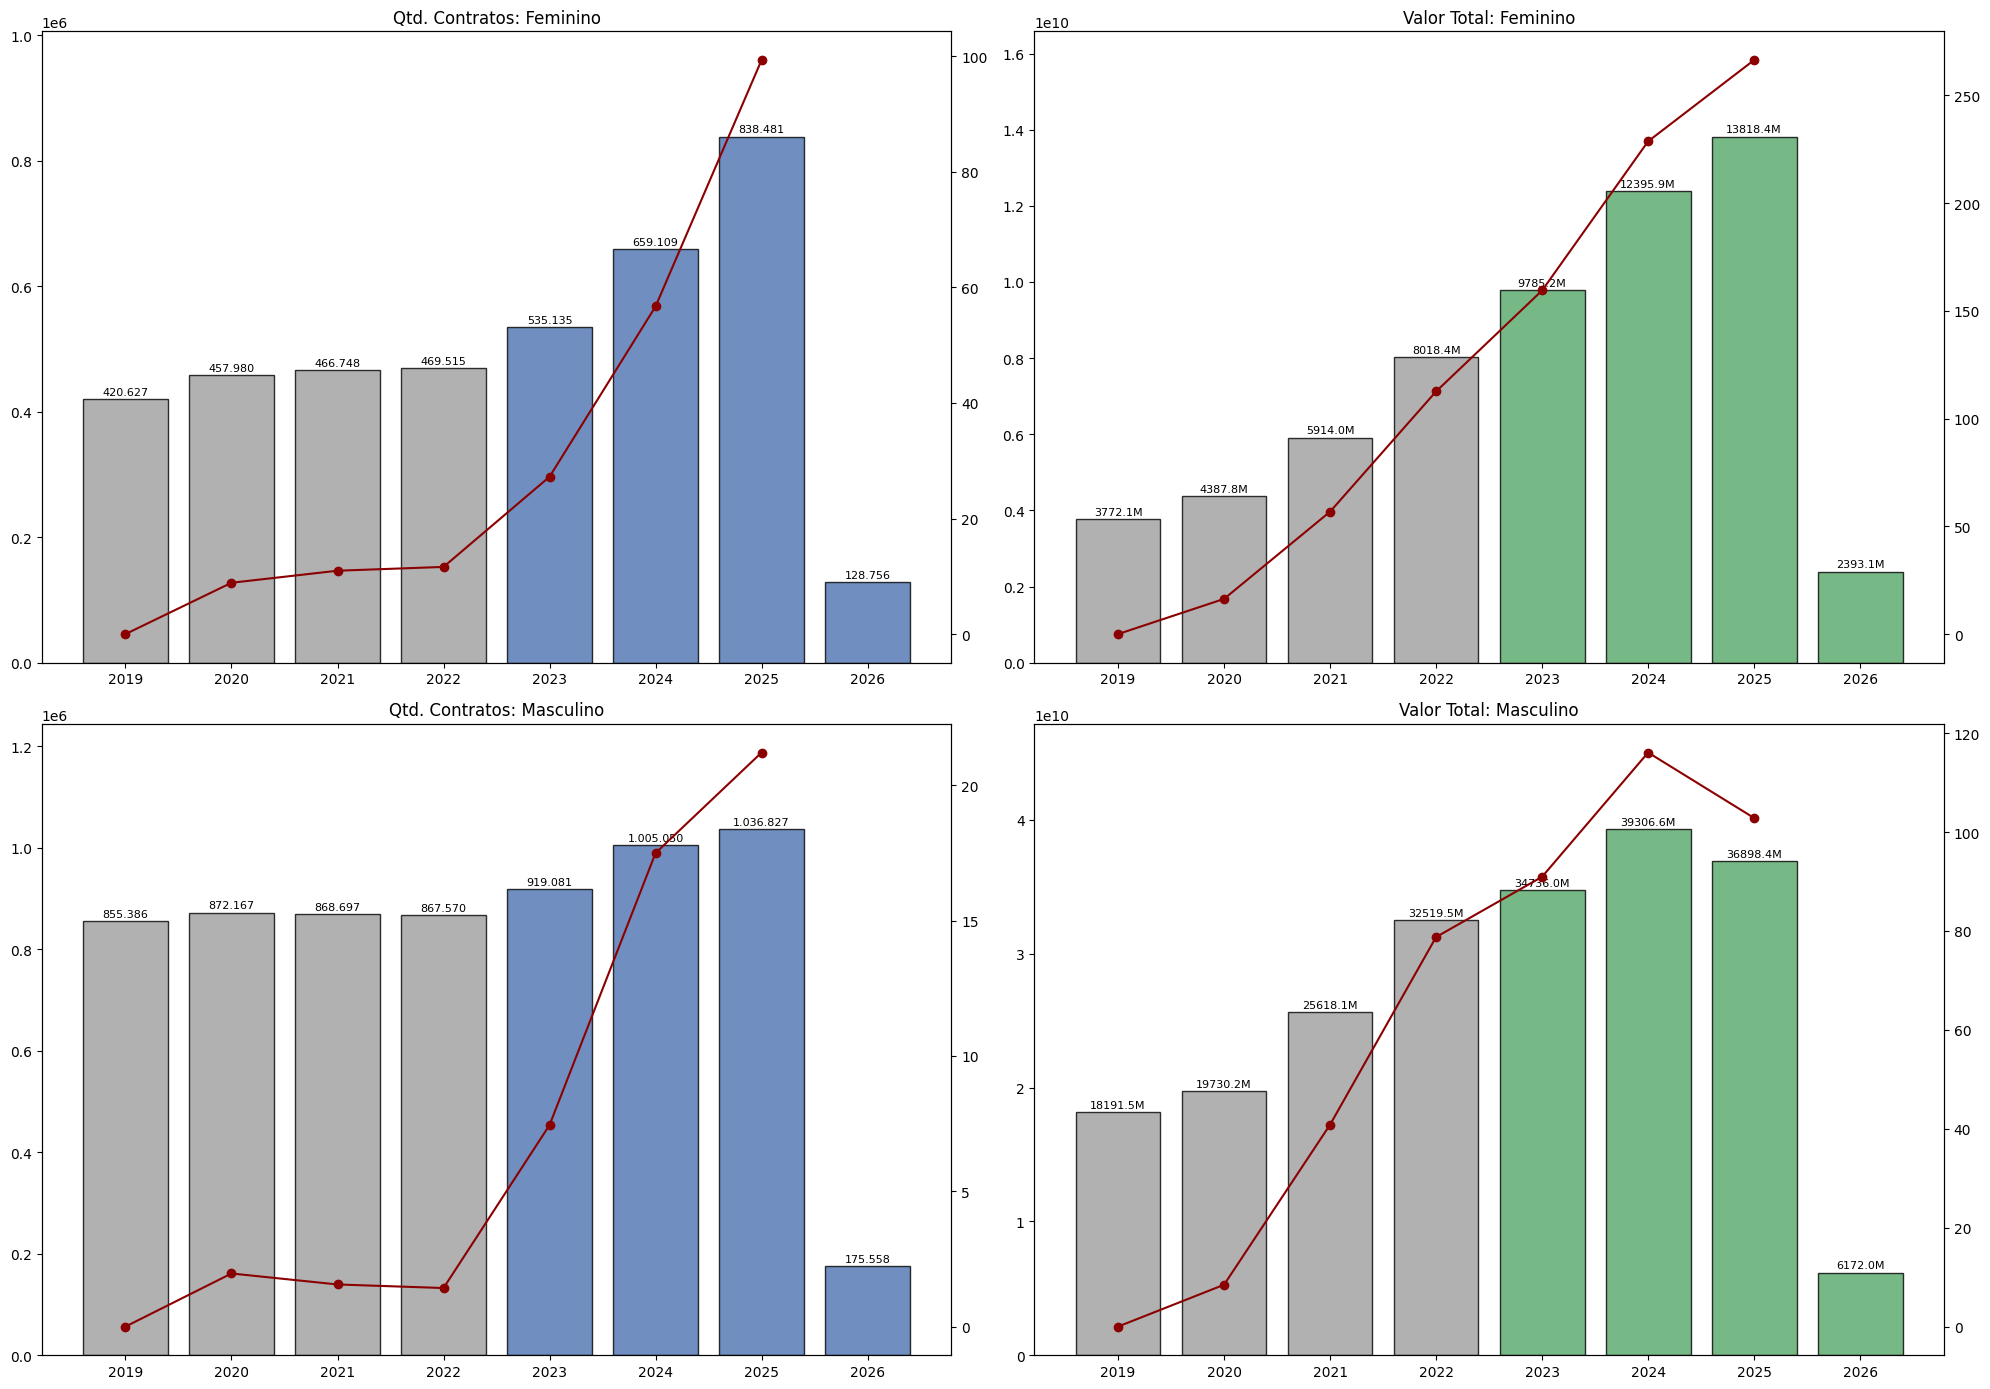

In [20]:
# Gráfico Público-alvo com Rótulos
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd
import os

# 1. Preparar dados
colunas_analise = ['qtd_contratos_anual_Feminino', 'valor_total_contratos_anual_Feminino', 'qtd_contratos_anual_Masculino', 'valor_total_contratos_anual_Masculino']
df_evolucao_plot = df_filtrado_plot.groupby('ANO_num')[colunas_analise].sum().reset_index()

for col in colunas_analise:
    base_val = df_evolucao_plot.loc[df_evolucao_plot['ANO_num'] == 2019, col].values[0]
    df_evolucao_plot[f'var_acum_{col}'] = ((df_evolucao_plot[col] / (base_val if base_val != 0 else 1)) - 1) * 100
df_linhas = df_evolucao_plot[df_evolucao_plot['ANO_num'] <= 2025].copy()

# Definir cores condicionais para as barras (Cinza para 2019-2022)
cores_qtd = ['#9E9E9E' if ano <= 2022 else '#4C72B0' for ano in df_evolucao_plot['ANO_num']]
cores_valor = ['#9E9E9E' if ano <= 2022 else '#55A868' for ano in df_evolucao_plot['ANO_num']]

# 2. Desenhar e SALVAR
fig, axes = plt.subplots(2, 2, figsize=(20, 14))
configuracoes = [('Feminino', 'qtd_contratos_anual_Feminino', 'valor_total_contratos_anual_Feminino', axes[0, 0], axes[0, 1]),
                 ('Masculino', 'qtd_contratos_anual_Masculino', 'valor_total_contratos_anual_Masculino', axes[1, 0], axes[1, 1])]

for titulo, col_q, col_v, ax1, ax2 in configuracoes:
    # Barras Qtd - Usando cores_qtd
    barras_q = ax1.bar(df_evolucao_plot['ANO_num'].astype(str), df_evolucao_plot[col_q], color=cores_qtd, alpha=0.8, edgecolor='black')
    ax1_twin = ax1.twinx()
    ax1_twin.plot(df_linhas['ANO_num'].astype(str), df_linhas[f'var_acum_{col_q}'], color='darkred', marker='o')
    ax1.set_title(f'Qtd. Contratos: {titulo}', fontsize=12)
    for b in barras_q:
        ax1.annotate(f'{int(b.get_height()):,}'.replace(',', '.'), xy=(b.get_x()+b.get_width()/2, b.get_height()), xytext=(0,3), textcoords="offset points", ha='center', fontsize=8)

    # Barras Valor - Usando cores_valor
    barras_v = ax2.bar(df_evolucao_plot['ANO_num'].astype(str), df_evolucao_plot[col_v], color=cores_valor, alpha=0.8, edgecolor='black')
    ax2_twin = ax2.twinx()
    ax2_twin.plot(df_linhas['ANO_num'].astype(str), df_linhas[f'var_acum_{col_v}'], color='darkred', marker='o')
    ax2.set_title(f'Valor Total: {titulo}', fontsize=12)
    for b in barras_v:
        ax2.annotate(f'{b.get_height()/1e6:.1f}M', xy=(b.get_x()+b.get_width()/2, b.get_height()), xytext=(0,3), textcoords="offset points", ha='center', fontsize=8)

    ax1.set_ylim(0, df_evolucao_plot[col_q].max() * 1.2)
    ax2.set_ylim(0, df_evolucao_plot[col_v].max() * 1.2)

plt.tight_layout()
plt.savefig('temp_publico_alvo.png', dpi=300)
plt.show()

# Dados Ater

In [21]:
import os
import glob
import pandas as pd

# Diretórios principais
RAW_DIR = '/content/drive/MyDrive/DAMEI_Relatorio_Dados/dados_brutos/dado_historico/ATER'
#ARQUIVO_ATUAL = '/content/drive/MyDrive/DAMEI_Relatorio_Dados/dados_brutos/dado_atual/pronaf_gaia_20260414_teste.xlsx'
OUTPUT_DIR = '/content/drive/MyDrive/DAMEI_Relatorio_Dados/dados_brutos/saida_teste'

# Garante que a pasta de saída exista
os.makedirs(OUTPUT_DIR, exist_ok=True)

# 1. Carregar os dados históricos da pasta
excel_files = glob.glob(os.path.join(RAW_DIR, '*.xlsx'))
excel_files.sort()

print(f'Foram encontrados {len(excel_files)} arquivos:')

# Dicionário para armazenar os DataFrames
bases_ater = {}

try:
    for f in excel_files:
        nome_arquivo = os.path.basename(f)
        print(f'  • Carregando aba "DADOS" de: {nome_arquivo}')
        # Carrega APENAS a aba 'Dados' de cada arquivo
        bases_ater[nome_arquivo] = pd.read_excel(f, sheet_name='DADOS')

    print('\nConcluído! Todos os dados históricos foram carregados.')

    # 2. Carregar o arquivo específico com o dado atual
    #nome_arquivo_atual = os.path.basename(ARQUIVO_ATUAL)
    #print(f'\nCarregando a base atual: {nome_arquivo_atual}')
    #bases_pronaf[nome_arquivo_atual] = pd.read_excel(ARQUIVO_ATUAL, sheet_name='Dados')
    #print(f'\nSucesso! Total de {len(bases_pronaf)} arquivos carregados.')

except OSError as e:
    print(f'\n❌ Erro de Conexão: {e}')
    print('DICA: O Google Drive parece ter desconectado. Tente remontar o Drive ou reiniciar o ambiente de execução.')

Foram encontrados 9 arquivos:
  • Carregando aba "DADOS" de: ater_ano_2018_ref_2025-11-30_gerado_em_20251212192827.xlsx
  • Carregando aba "DADOS" de: ater_ano_2019_ref_2025-11-30_gerado_em_20251212192827.xlsx
  • Carregando aba "DADOS" de: ater_ano_2020_ref_2025-11-30_gerado_em_20251212192827.xlsx
  • Carregando aba "DADOS" de: ater_ano_2021_ref_2025-11-30_gerado_em_20251212192827.xlsx
  • Carregando aba "DADOS" de: ater_ano_2022_ref_2025-11-30_gerado_em_20251212192827.xlsx
  • Carregando aba "DADOS" de: ater_ano_2023_ref_2025-11-30_gerado_em_20251212192827.xlsx
  • Carregando aba "DADOS" de: ater_ano_2024_ref_2025-11-30_gerado_em_20251212192827.xlsx
  • Carregando aba "DADOS" de: ater_ate_2025_12_gerado_em_20260114105014.xlsx
  • Carregando aba "DADOS" de: ater_ate_2026_03_gerado_em_20260410151127.xlsx

Concluído! Todos os dados históricos foram carregados.


In [22]:
# Iterar por todas as tabelas, mostrar cabeçalho e o somatório das colunas
print(f"Analisando {len(bases_ater)} tabelas:\n")

for nome, df in bases_ater.items():
    print(f"{'='*60}")
    print(f"ARQUIVO: {nome}")
    print(f"{'='*60}")

    # Mostrar o cabeçalho (nomes das colunas)
    print(f"\n⌒ CABEÇALHO:\n{list(df.columns)}")

    # Calcular somatório apenas das colunas numéricas
    colunas_numericas = df.select_dtypes(include=['number']).columns
    if not colunas_numericas.empty:
        print(f"\n∑ SOMATÓRIO DAS COLUNAS NUMÉRICAS:")
        display(df[colunas_numericas].sum().to_frame(name='Total'))
    else:
        print("\n⚠ Nenhuma coluna numérica encontrada para somar.")

    print("\n")

Analisando 9 tabelas:

ARQUIVO: ater_ano_2018_ref_2025-11-30_gerado_em_20251212192827.xlsx

⌒ CABEÇALHO:
['dt_referencia', 'dt_geracao', 'ano', 'cod_ibge', 'nome_municipio', 'uf', 'Quantidade de atendimentos_ano', 'Soma de familias_com_ater_recebida_no_ano', 'Soma de familias_com_ater_iniciada_no_ano', 'media_atendimentos_por_familia']

∑ SOMATÓRIO DAS COLUNAS NUMÉRICAS:


,Total
ano,2.484158e+06
cod_ibge,3.567875e+09
Quantidade de atendimentos_ano,1.908610e+05
Soma de familias_com_ater_recebida_no_ano,5.838200e+04
Soma de familias_com_ater_iniciada_no_ano,5.597100e+04
media_atendimentos_por_familia,4.503103e+03




ARQUIVO: ater_ano_2019_ref_2025-11-30_gerado_em_20251212192827.xlsx

⌒ CABEÇALHO:
['dt_referencia', 'dt_geracao', 'ano', 'cod_ibge', 'nome_municipio', 'uf', 'Quantidade de atendimentos_ano', 'Soma de familias_com_ater_recebida_no_ano', 'Soma de familias_com_ater_iniciada_no_ano', 'media_atendimentos_por_familia']

∑ SOMATÓRIO DAS COLUNAS NUMÉRICAS:


,Total
ano,2.917455e+06
cod_ibge,4.280296e+09
Quantidade de atendimentos_ano,2.713150e+05
Soma de familias_com_ater_recebida_no_ano,8.079000e+04
Soma de familias_com_ater_iniciada_no_ano,2.857200e+04
media_atendimentos_por_familia,4.742265e+03




ARQUIVO: ater_ano_2020_ref_2025-11-30_gerado_em_20251212192827.xlsx

⌒ CABEÇALHO:
['dt_referencia', 'dt_geracao', 'ano', 'cod_ibge', 'nome_municipio', 'uf', 'Quantidade de atendimentos_ano', 'Soma de familias_com_ater_recebida_no_ano', 'Soma de familias_com_ater_iniciada_no_ano', 'media_atendimentos_por_familia']

∑ SOMATÓRIO DAS COLUNAS NUMÉRICAS:


...

,Total
ano,1.056528e+06
cod_ibge,1.637544e+09
Quantidade de atendimentos_ano,1.609870e+05
Soma de familias_com_ater_recebida_no_ano,2.793000e+04
Soma de familias_com_ater_iniciada_no_ano,1.233600e+04
media_atendimentos_por_familia,2.867867e+03




ARQUIVO: ater_ate_2025_12_gerado_em_20260114105014.xlsx

⌒ CABEÇALHO:
['dt_referencia', 'dt_geracao', 'cod_ibge', 'nome_municipio', 'uf', 'familias_com_ater_iniciada_no_ano', 'familias_com_ater_recebida_no_ano']

∑ SOMATÓRIO DAS COLUNAS NUMÉRICAS:


,Total
dt_geracao,9664074378
cod_ibge,1490799248
familias_com_ater_iniciada_no_ano,10689
familias_com_ater_recebida_no_ano,24898




ARQUIVO: ater_ate_2026_03_gerado_em_20260410151127.xlsx

⌒ CABEÇALHO:
['dt_referencia', 'dt_geracao', 'cod_ibge', 'nome_municipio', 'uf', 'familias_com_ater_iniciada_no_ano', 'familias_com_ater_recebida_no_ano']

∑ SOMATÓRIO DAS COLUNAS NUMÉRICAS:


,Total
dt_geracao,6645414480
cod_ibge,998740976
familias_com_ater_iniciada_no_ano,5785
familias_com_ater_recebida_no_ano,16855


In [23]:
# Renomear colunas em todas as tabelas de ATER
print("Renomeando colunas nas bases ATER...")

for nome_arquivo, df in bases_ater.items():
    if 'familias_com_ater_recebida_no_ano' in df.columns:
        df.rename(columns={'familias_com_ater_recebida_no_ano': 'Soma de familias_com_ater_recebida_no_ano'}, inplace=True)
        print(f"  ✅ Coluna renomeada em: {nome_arquivo}")

print("\nProcedimento concluído!")

# Mostrar o cabeçalho do ùltimo arquivo processado
print(f"\n⌒ CABEÇALHO:\n{list(df.columns)}")

Renomeando colunas nas bases ATER...
  ✅ Coluna renomeada em: ater_ate_2025_12_gerado_em_20260114105014.xlsx
  ✅ Coluna renomeada em: ater_ate_2026_03_gerado_em_20260410151127.xlsx

Procedimento concluído!

⌒ CABEÇALHO:
['dt_referencia', 'dt_geracao', 'cod_ibge', 'nome_municipio', 'uf', 'familias_com_ater_iniciada_no_ano', 'Soma de familias_com_ater_recebida_no_ano']


In [24]:
# Selecionar apenas as colunas desejadas nas bases de ATER
colunas_selecionadas = [
    'dt_referencia', 'dt_geracao', 'cod_ibge',
    'nome_municipio', 'uf', 'Soma de familias_com_ater_recebida_no_ano'
]

print("Filtrando colunas nas bases ATER...")

for nome_arquivo in bases_ater.keys():
    # Filtra apenas as colunas que existem no DataFrame para evitar KeyError
    colunas_existentes = [c for c in colunas_selecionadas if c in bases_ater[nome_arquivo].columns]
    bases_ater[nome_arquivo] = bases_ater[nome_arquivo][colunas_existentes]
    print(f"  ✅ Colunas selecionadas em: {nome_arquivo} ({len(colunas_existentes)} colunas mantidas)")

print("\nFiltro aplicado com sucesso!")

Filtrando colunas nas bases ATER...
  ✅ Colunas selecionadas em: ater_ano_2018_ref_2025-11-30_gerado_em_20251212192827.xlsx (6 colunas mantidas)
  ✅ Colunas selecionadas em: ater_ano_2019_ref_2025-11-30_gerado_em_20251212192827.xlsx (6 colunas mantidas)
  ✅ Colunas selecionadas em: ater_ano_2020_ref_2025-11-30_gerado_em_20251212192827.xlsx (6 colunas mantidas)
  ✅ Colunas selecionadas em: ater_ano_2021_ref_2025-11-30_gerado_em_20251212192827.xlsx (6 colunas mantidas)
  ✅ Colunas selecionadas em: ater_ano_2022_ref_2025-11-30_gerado_em_20251212192827.xlsx (6 colunas mantidas)
  ✅ Colunas selecionadas em: ater_ano_2023_ref_2025-11-30_gerado_em_20251212192827.xlsx (6 colunas mantidas)
  ✅ Colunas selecionadas em: ater_ano_2024_ref_2025-11-30_gerado_em_20251212192827.xlsx (6 colunas mantidas)
  ✅ Colunas selecionadas em: ater_ate_2025_12_gerado_em_20260114105014.xlsx (6 colunas mantidas)
  ✅ Colunas selecionadas em: ater_ate_2026_03_gerado_em_20260410151127.xlsx (6 colunas mantidas)

Filtro

In [25]:
# Consolidar bases ATER em um único DataFrame
lista_dfs_ater = []

for nome_arquivo, df in bases_ater.items():
    df_temp = df.copy()
    df_temp['arquivo_origem'] = nome_arquivo
    lista_dfs_ater.append(df_temp)

df_ater_consolidado = pd.concat(lista_dfs_ater, ignore_index=True)

# Converter cod_ibge para string para manter o padrão
if 'cod_ibge' in df_ater_consolidado.columns:
    df_ater_consolidado['cod_ibge'] = df_ater_consolidado['cod_ibge'].astype(str)

print("✅ Bases ATER consolidadas com sucesso!")
print(f"Total de linhas: {df_ater_consolidado.shape[0]}")
display(df_ater_consolidado.head())

✅ Bases ATER consolidadas com sucesso!
Total de linhas: 7174


,dt_referencia,dt_geracao,cod_ibge,nome_municipio,uf,Soma de familias_com_ater_recebida_no_ano,arquivo_origem
0,2025-11-30,2025-12-12,1100023,ARIQUEMES-RO,RO,50,ater_ano_2018_ref_2025-11-30_gerado_em_2025121...
1,2025-11-30,2025-12-12,1100049,CACOAL-RO,RO,50,ater_ano_2018_ref_2025-11-30_gerado_em_2025121...
2,2025-11-30,2025-12-12,1100205,PORTO VELHO-RO,RO,50,ater_ano_2018_ref_2025-11-30_gerado_em_2025121...
3,2025-11-30,2025-12-12,1100320,SÃO MIGUEL DO GUAPORE-RO,RO,50,ater_ano_2018_ref_2025-11-30_gerado_em_2025121...
4,2025-11-30,2025-12-12,1100346,ALVORADA DOESTE-RO,RO,50,ater_ano_2018_ref_2025-11-30_gerado_em_2025121...


In [26]:
import pandas as pd

# 1. Definir as listas de colunas para tratamento
colunas_texto_ater = [
    'dt_referencia', 'dt_geracao', 'cod_ibge',
    'nome_municipio', 'uf', 'arquivo_origem'
]

coluna_numero_ater = 'Soma de familias_com_ater_recebida_no_ano'

print("Iniciando o tratamento dos dados ATER...")

# 2. Tratamento das colunas de texto (Conversão e limpeza de espaços)
for col in colunas_texto_ater:
    if col in df_ater_consolidado.columns:
        df_ater_consolidado[col] = df_ater_consolidado[col].astype(str).str.strip()

# 3. Tratamento da coluna numérica
if coluna_numero_ater in df_ater_consolidado.columns:
    df_ater_consolidado[coluna_numero_ater] = pd.to_numeric(df_ater_consolidado[coluna_numero_ater], errors='coerce').fillna(0)

print("✅ Tratamento ATER concluído com sucesso!")
print("-" * 50)
print("Resumo dos tipos de dados:")
print(df_ater_consolidado.dtypes)
display(df_ater_consolidado.head())


Iniciando o tratamento dos dados ATER...
✅ Tratamento ATER concluído com sucesso!
--------------------------------------------------
Resumo dos tipos de dados:
dt_referencia                                object
dt_geracao                                   object
cod_ibge                                     object
nome_municipio                               object
uf                                           object
Soma de familias_com_ater_recebida_no_ano     int64
arquivo_origem                               object
dtype: object


,dt_referencia,dt_geracao,cod_ibge,nome_municipio,uf,Soma de familias_com_ater_recebida_no_ano,arquivo_origem
0,2025-11-30,2025-12-12,1100023,ARIQUEMES-RO,RO,50,ater_ano_2018_ref_2025-11-30_gerado_em_2025121...
1,2025-11-30,2025-12-12,1100049,CACOAL-RO,RO,50,ater_ano_2018_ref_2025-11-30_gerado_em_2025121...
2,2025-11-30,2025-12-12,1100205,PORTO VELHO-RO,RO,50,ater_ano_2018_ref_2025-11-30_gerado_em_2025121...
3,2025-11-30,2025-12-12,1100320,SÃO MIGUEL DO GUAPORE-RO,RO,50,ater_ano_2018_ref_2025-11-30_gerado_em_2025121...
4,2025-11-30,2025-12-12,1100346,ALVORADA DOESTE-RO,RO,50,ater_ano_2018_ref_2025-11-30_gerado_em_2025121...


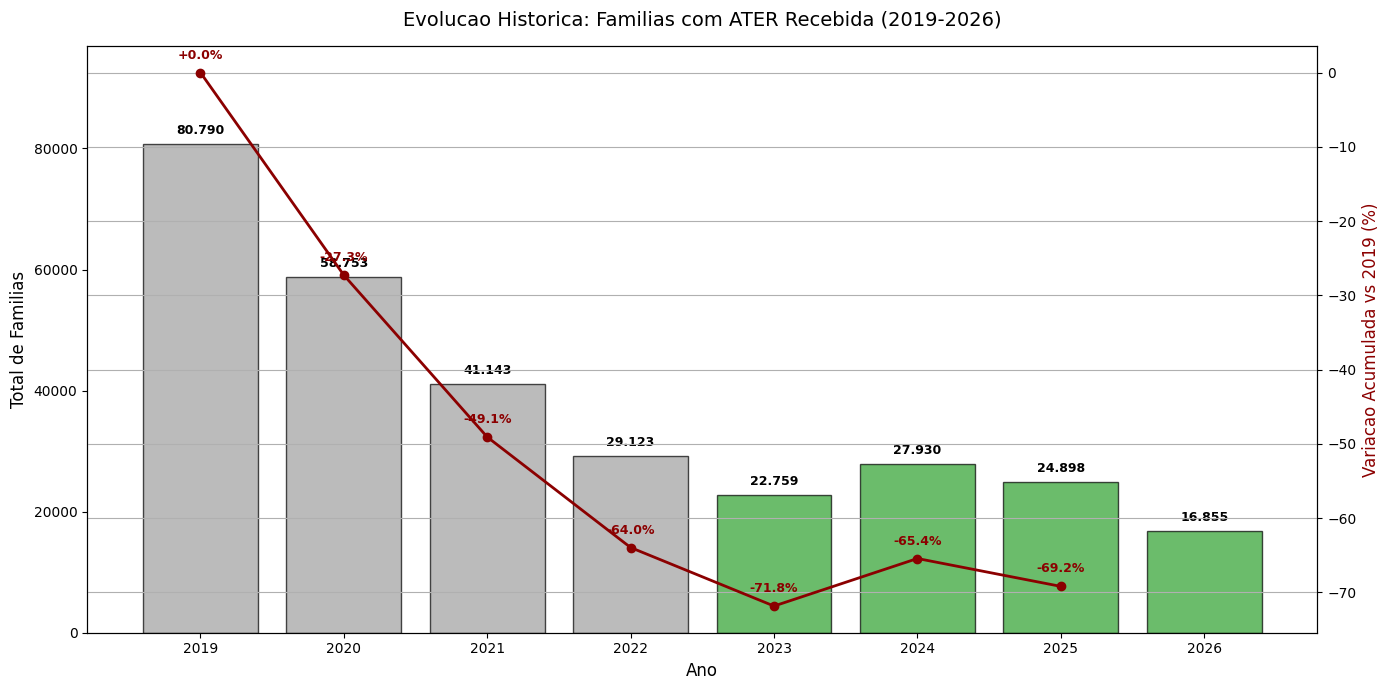

In [27]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd
import re
import os

# 1. Extrair o ano e filtrar
def extrair_ano(nome):
    match = re.search(r'(\d{4})', nome)
    return int(match.group(1)) if match else None

df_ater_consolidado['ANO_num'] = df_ater_consolidado['arquivo_origem'].apply(extrair_ano)

# Filtrar 2019 a 2026
df_ater_filtrado = df_ater_consolidado[(df_ater_consolidado['ANO_num'] >= 2019) & (df_ater_consolidado['ANO_num'] <= 2026)].copy()

# 2. Agrupar por ano
df_evolucao_ater = df_ater_filtrado.groupby('ANO_num')['Soma de familias_com_ater_recebida_no_ano'].sum().reset_index()
df_evolucao_ater = df_evolucao_ater.sort_values('ANO_num')

# 3. Calcular Variacao Acumulada (Base 2019, ate 2025)
base_2019 = df_evolucao_ater.loc[df_evolucao_ater['ANO_num'] == 2019, 'Soma de familias_com_ater_recebida_no_ano'].values[0]
df_evolucao_ater['var_acum'] = ((df_evolucao_ater['Soma de familias_com_ater_recebida_no_ano'] / base_2019) - 1) * 100
df_linhas_ater = df_evolucao_ater[(df_evolucao_ater['ANO_num'] >= 2019) & (df_evolucao_ater['ANO_num'] <= 2025)].copy()

# 4. Desenhar
fig, ax1 = plt.subplots(figsize=(14, 7))

# Barras
cores_ater = ['#9E9E9E' if ano <= 2022 else '#2CA02C' for ano in df_evolucao_ater['ANO_num']]
barras = ax1.bar(df_evolucao_ater['ANO_num'].astype(str), df_evolucao_ater['Soma de familias_com_ater_recebida_no_ano'], color=cores_ater, edgecolor='black', alpha=0.7)

# Linha de Variacao (Eixo Secundario)
ax2 = ax1.twinx()
ax2.plot(df_linhas_ater['ANO_num'].astype(str), df_linhas_ater['var_acum'], color='darkred', marker='o', linewidth=2, label='Var. Acumulada (%)')

# Formatacao
ax1.set_title('Evolucao Historica: Familias com ATER Recebida (2019-2026)', fontsize=14, pad=15)
ax1.set_xlabel('Ano', fontsize=12)
ax1.set_ylabel('Total de Familias', fontsize=12)
ax2.set_ylabel('Variacao Acumulada vs 2019 (%)', fontsize=12, color='darkred')

# Adicionar rotulos nas barras
for barra in barras:
    altura = barra.get_height()
    ax1.annotate(f'{int(altura):,}'.replace(',', '.'),
                 xy=(barra.get_x() + barra.get_width() / 2, altura),
                 xytext=(0, 5), textcoords="offset points", ha='center', va='bottom', fontsize=9, fontweight='bold')

# Adicionar rotulos na linha
for x, y in zip(df_linhas_ater['ANO_num'].astype(str), df_linhas_ater['var_acum']):
    ax2.annotate(f'{y:+.1f}%', xy=(x, y), xytext=(0, 10), textcoords="offset points", ha='center', color='darkred', fontsize=9, fontweight='bold')

ax1.set_ylim(0, df_evolucao_ater['Soma de familias_com_ater_recebida_no_ano'].max() * 1.2)
ax2.grid(None)
plt.tight_layout()

# SALVAR O GRAFICO
plt.savefig('temp_ater.png', dpi=300)
plt.show()

In [28]:
# 1. Calcular somatórias por períodos específicos
soma_2019_2021 = df_evolucao_ater[
    (df_evolucao_ater['ANO_num'] >= 2019) & (df_evolucao_ater['ANO_num'] <= 2021)
]['Soma de familias_com_ater_recebida_no_ano'].sum()

soma_2023_2025 = df_evolucao_ater[
    (df_evolucao_ater['ANO_num'] >= 2023) & (df_evolucao_ater['ANO_num'] <= 2025)
]['Soma de familias_com_ater_recebida_no_ano'].sum()

# 2. Calcular variação absoluta e percentual
variacao_absoluta = soma_2023_2025 - soma_2019_2021
variacao_percentual = (variacao_absoluta / soma_2019_2021) * 100

# 3. Exibir resultados
print(f"📊 COMPARATIVO DE FAMÍLIAS COM ATER RECEBIDA")
print("-" * 50)
print(f"Período 2019-2021: {int(soma_2019_2021):,} famílias".replace(',', '.'))
print(f"Período 2023-2025: {int(soma_2023_2025):,} famílias".replace(',', '.'))
print("-" * 50)
print(f"Variação Absoluta: {int(variacao_absoluta):,} famílias".replace(',', '.'))
print(f"Variação Percentual: {variacao_percentual:+.2f}%")

📊 COMPARATIVO DE FAMÍLIAS COM ATER RECEBIDA
--------------------------------------------------
Período 2019-2021: 180.686 famílias
Período 2023-2025: 75.587 famílias
--------------------------------------------------
Variação Absoluta: -105.099 famílias
Variação Percentual: -58.17%


In [29]:
import pandas as pd

# 1. Filtrar os dados para o ano de 2023 (ano base completo)
df_ater_2023 = df_ater_consolidado[df_ater_consolidado['ANO_num'] == 2025].copy()

# 2. Agrupar por Município e UF e somar os atendimentos
ranking_ater = df_ater_2023.groupby(['nome_municipio', 'uf'])['Soma de familias_com_ater_recebida_no_ano'].sum().reset_index()

# 3. Ordenar pelos maiores valores e pegar os top 3
top_3_ater_2023 = ranking_ater.sort_values(by='Soma de familias_com_ater_recebida_no_ano', ascending=False).head(3)

print("🏆 RANKING: 3 MAIORES MUNICÍPIOS EM ATENDIMENTO ATER (2025)")
print("-" * 60)
display(top_3_ater_2023.rename(columns={'Soma de familias_com_ater_recebida_no_ano': 'Total de Famílias Atendidas'}))

🏆 RANKING: 3 MAIORES MUNICÍPIOS EM ATENDIMENTO ATER (2025)
------------------------------------------------------------


,nome_municipio,uf,Total de Famílias Atendidas
49,Belterra,PA,844
453,Tracuateua,PA,750
439,São Sebastião Da Boa Vis,PA,659


Proposta de Texto

# Relatório de Dados

In [30]:
!apt-get update
!apt-get install -y libreoffice
!pip install -q python-docx

Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:2 https://cli.github.com/packages stable InRelease [3,917 B]
Get:3 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [89.0 kB]
Get:4 https://cli.github.com/packages stable/main amd64 Packages [356 B]
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:6 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:7 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:8 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:10 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [2,991 kB]
Hit:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:12 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy/main amd64 Packages [38.8 kB]
Get:13 http://security.ubuntu.com/ubuntu jammy-security/multiverse amd64 Package

In [31]:
!pip install python-docx

In [32]:
import os
import subprocess
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from docx import Document
from docx.shared import Pt, Inches
from docx.enum.text import WD_ALIGN_PARAGRAPH
from docx.oxml.ns import qn
import pandas as pd

# --- FUNÇÕES DE APOIO ---
def set_font_style(paragraph, font_name='Arial', font_size=11, bold=False):
    for run in paragraph.runs:
        run.font.name = font_name
        run.font.size = Pt(font_size)
        run.bold = bold
        run._element.rPr.rFonts.set(qn('w:eastAsia'), font_name)

def formata_v(valor):
    return f'{valor:,.0f}'.replace(',', '.')

def formata_r(valor):
    return f'R$ {valor/1e6:,.1f} Mi'.replace(',', 'X').replace('.', ',').replace('X', '.')

# --- CONFIGURAÇÕES DE DADOS ---
# Garantir que os anos estão como números
df_pronaf_consolidado['ANO_num'] = pd.to_numeric(df_pronaf_consolidado['ANO'], errors='coerce')
# Extrair ano do ATER se não existir
if 'ANO_num' not in df_ater_consolidado.columns:
    import re
    df_ater_consolidado['ANO_num'] = df_ater_consolidado['arquivo_origem'].apply(lambda x: int(re.search(r'(\d{4})', x).group(1)) if re.search(r'(\d{4})', x) else None)

# Totais Brasil para 2026 (Referência)
br_2026_v = df_pronaf_consolidado[df_pronaf_consolidado['ANO_num'] == 2026]['valor_contratos_total'].sum()
br_2026_a = df_ater_consolidado[df_ater_consolidado['ANO_num'] == 2026]['Soma de familias_com_ater_recebida_no_ano'].sum()

# Lista de UFs + Brasil
lista_targets = sorted([uf for uf in df_pronaf_consolidado['uf'].unique() if str(uf) != 'nan']) + ['BRASIL']

print(f"🚀 Iniciando geração de {len(lista_targets)} relatórios...")

for alvo in lista_targets:
    is_br = (alvo == 'BRASIL')
    doc = Document()

    # Cabeçalho Principal
    title = doc.add_heading(f'Relatório de Monitoramento: {alvo}', 0)
    title.alignment = WD_ALIGN_PARAGRAPH.CENTER

    # Filtro de dados
    df_p_alvo = df_pronaf_consolidado if is_br else df_pronaf_consolidado[df_pronaf_consolidado['uf'] == alvo]
    df_a_alvo = df_ater_consolidado if is_br else df_ater_consolidado[df_ater_consolidado['uf'] == alvo]

    # --- SEÇÃO 1: PRONAF ---
    doc.add_heading('1. Crédito Rural (PRONAF)', level=1)
    val_26 = df_p_alvo[df_p_alvo['ANO_num'] == 2026]['valor_contratos_total'].sum()
    p = doc.add_paragraph(f"Em 2026, o montante contratado em {alvo} foi de {formata_r(val_26)}.")
    if not is_br:
        part = (val_26 / br_2026_v * 100) if br_2026_v > 0 else 0
        p.add_run(f" Isso representa {part:.2f}% da participação nacional.").bold = True

    # Gráfico PRONAF
    df_ev_p = df_p_alvo[(df_p_alvo['ANO_num'] >= 2019) & (df_p_alvo['ANO_num'] <= 2026)].groupby('ANO_num')['valor_contratos_total'].sum().reset_index()
    if not df_ev_p.empty:
        plt.figure(figsize=(10, 5))
        ax1 = plt.gca()
        cores = ['#9E9E9E' if a <= 2022 else '#4C72B0' for a in df_ev_p['ANO_num']]
        bars = ax1.bar(df_ev_p['ANO_num'].astype(str), df_ev_p['valor_contratos_total'], color=cores, alpha=0.8)

        # Linha de Variação Acumulada
        base_19 = df_ev_p.loc[df_ev_p['ANO_num'] == 2019, 'valor_contratos_total'].values[0] if 2019 in df_ev_p['ANO_num'].values else df_ev_p.iloc[0,1]
        ax2 = ax1.twinx()
        ax2.plot(df_ev_p[df_ev_p['ANO_num'] <= 2025]['ANO_num'].astype(str), ((df_ev_p[df_ev_p['ANO_num'] <= 2025]['valor_contratos_total']/base_19)-1)*100, color='darkred', marker='o')

        plt.title(f'Evolução PRONAF - {alvo}')
        p_img = f'p_{alvo}.png'
        plt.savefig(p_img, dpi=120); plt.close()
        doc.add_picture(p_img, width=Inches(5.5))
        os.remove(p_img)

    doc.add_page_break()

    # --- SEÇÃO 2: ATER ---
    doc.add_heading('2. Assistência Técnica (ATER)', level=1)
    ater_26 = df_a_alvo[df_a_alvo['ANO_num'] == 2026]['Soma de familias_com_ater_recebida_no_ano'].sum()
    doc.add_paragraph(f"Total de famílias com ATER recebida em 2026: {formata_v(ater_26)}.")

    # Gráfico ATER
    df_ev_a = df_a_alvo[(df_a_alvo['ANO_num'] >= 2019) & (df_a_alvo['ANO_num'] <= 2026)].groupby('ANO_num')['Soma de familias_com_ater_recebida_no_ano'].sum().reset_index()
    if not df_ev_a.empty:
        plt.figure(figsize=(10, 5))
        ax1 = plt.gca()
        cores_a = ['#9E9E9E' if a <= 2022 else '#2CA02C' for a in df_ev_a['ANO_num']]
        ax1.bar(df_ev_a['ANO_num'].astype(str), df_ev_a['Soma de familias_com_ater_recebida_no_ano'], color=cores_a, alpha=0.8)
        plt.title(f'Evolução ATER - {alvo}')
        a_img = f'a_{alvo}.png'
        plt.savefig(a_img, dpi=120); plt.close()
        doc.add_picture(a_img, width=Inches(5.5))
        os.remove(a_img)

    # Salvar e Converter
    fname = f"Relatorio_Monitoramento_{alvo.replace(' ', '_')}"
    doc.save(f"{fname}.docx")
    subprocess.run(['libreoffice', '--headless', '--convert-to', 'pdf', '--outdir', OUTPUT_DIR, f"{fname}.docx"], capture_output=True)
    os.remove(f"{fname}.docx")
    print(f"✅ PDF Gerado: {alvo}")

print(f"\n⭐ Processo concluído. Arquivos salvos em: {OUTPUT_DIR}")

🚀 Iniciando geração de 28 relatórios...
✅ PDF Gerado: AC
✅ PDF Gerado: AL
✅ PDF Gerado: AM
✅ PDF Gerado: AP
✅ PDF Gerado: BA
✅ PDF Gerado: CE
✅ PDF Gerado: DF
✅ PDF Gerado: ES
✅ PDF Gerado: GO
✅ PDF Gerado: MA
✅ PDF Gerado: MG
✅ PDF Gerado: MS
✅ PDF Gerado: MT
✅ PDF Gerado: PA
✅ PDF Gerado: PB
✅ PDF Gerado: PE
✅ PDF Gerado: PI
✅ PDF Gerado: PR
✅ PDF Gerado: RJ
✅ PDF Gerado: RN
✅ PDF Gerado: RO
✅ PDF Gerado: RR
✅ PDF Gerado: RS
✅ PDF Gerado: SC
✅ PDF Gerado: SE
✅ PDF Gerado: SP
✅ PDF Gerado: TO
✅ PDF Gerado: BRASIL

⭐ Processo concluído. Arquivos salvos em: /content/drive/MyDrive/DAMEI_Relatorio_Dados/dados_brutos/saida_teste


# Relatório de Monitoramento

Este relatório está dividido em três seções principais, cada uma contendo tabelas de execução, gráficos de evolução histórica com indicadores de variação e rankings municipais.

In [33]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd
import numpy as np

# Função mestre para os gráficos do relatório
def gerar_grafico_secao(df_ev, col_valor, titulo, label_y, cor_periodos):
    fig, ax1 = plt.subplots(figsize=(14, 7))
    anos_str = df_ev['ANO_num'].astype(str)

    # Barras com cores condicionais (Cinza até 2022, Azul 2023+)
    cores = ['#9E9E9E' if int(ano) <= 2022 else '#4C72B0' for ano in anos_str]
    bars = ax1.bar(anos_str, df_ev[col_valor], color=cores, alpha=0.8, edgecolor='black')

    # Eixo Secundário: Variação Acumulada (2019-2025)
    df_v = df_ev[df_ev['ANO_num'] <= 2025].copy()
    base = df_v.loc[df_v['ANO_num'] == 2019, col_valor].values[0]
    df_v['var_acum'] = ((df_v[col_valor] / base) - 1) * 100

    ax2 = ax1.twinx()
    ax2.plot(df_v['ANO_num'].astype(str), df_v['var_acum'], color='darkred', marker='o', linewidth=2.5, label='Var. Acumulada (%)')
    ax2.yaxis.set_major_formatter(ticker.PercentFormatter())
    ax2.set_ylabel('Crescimento Acumulado vs 2019 (%)', color='darkred', fontweight='bold')

    # Formatação
    ax1.set_title(titulo, fontsize=15, pad=20, fontweight='bold')
    ax1.set_ylabel(label_y, fontsize=12)
    ax1.grid(axis='y', linestyle='--', alpha=0.5)

    # Rótulos nas barras
    for b in bars:
        h = b.get_height()
        label = f'R$ {h/1e9:.1f}B' if h > 1e9 else (f'R$ {h/1e6:.1f}M' if h > 1e6 else f'{int(h):,}')
        ax1.annotate(label, xy=(b.get_x() + b.get_width()/2, h), xytext=(0, 5), textcoords='offset points', ha='center', fontsize=9, fontweight='bold')

    plt.tight_layout()
    plt.show()

## Seção 1: PRONAF (Crédito Rural)

TABELA: Execução PRONAF por UF (Março/2026)


,uf,valor_contratos_total,qtd_contratos_total
22,RS,"R$ 2,311,754,077.88",31384
23,SC,"R$ 1,706,160,904.82",18872
17,PR,"R$ 1,684,841,253.74",19655
10,MG,"R$ 1,604,294,782.57",44848
4,BA,"R$ 1,229,653,837.93",84248
7,ES,"R$ 749,403,823.99",8603
13,PA,"R$ 658,786,280.49",14770
20,RO,"R$ 518,539,180.94",6174
15,PE,"R$ 443,450,727.55",37375
9,MA,"R$ 428,622,270.23",34582


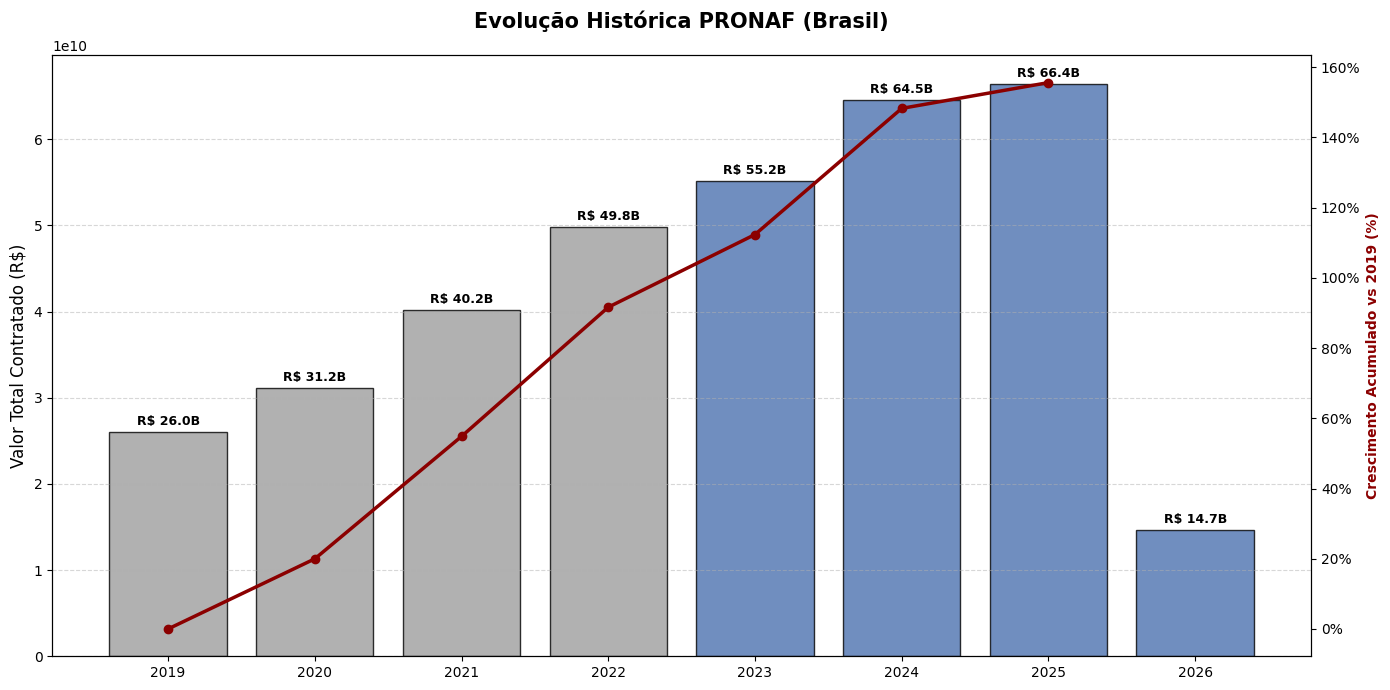


RANKING: 10 Maiores Municípios PRONAF (2025)


,nome_municipio,uf,valor_contratos_total
4406,Sem Informacao,RS,4.562831e+09
4407,Sem Informacao,SC,4.279402e+09
4394,Sem Informacao,MG,3.192673e+09
4401,Sem Informacao,PR,2.160157e+09
4404,Sem Informacao,RO,1.087121e+09
4391,Sem Informacao,ES,1.056655e+09
4397,Sem Informacao,PA,8.206916e+08
4388,Sem Informacao,BA,7.890200e+08
4409,Sem Informacao,SP,4.438122e+08
4393,Sem Informacao,MA,4.092801e+08



COMPARATIVO EXECUÇÃO:
- Triênio 2019-2021: R$ 97.39 Bi
- Triênio 2023-2025: R$ 186.08 Bi
- Variação: +91.07%


In [ ]:
# 1. Tabela 2026
tab_p_26 = df_pronaf_consolidado[df_pronaf_consolidado['ANO_num'] == 2026].groupby('uf')[['valor_contratos_total', 'qtd_contratos_total']].sum().reset_index()
print("TABELA: Execução PRONAF por UF (Março/2026)")
display(tab_p_26.sort_values('valor_contratos_total', ascending=False).style.format({'valor_contratos_total': 'R$ {:,.2f}'}))

# 2. Gráfico Evolução
df_ev_p = df_pronaf_consolidado[(df_pronaf_consolidado['ANO_num'] >= 2019) & (df_pronaf_consolidado['ANO_num'] <= 2026)].groupby('ANO_num')['valor_contratos_total'].sum().reset_index()
gerar_grafico_secao(df_ev_p, 'valor_contratos_total', 'Evolução Histórica PRONAF (Brasil)', 'Valor Total Contratado (R$)', None)

# 3. Ranking Municípios (2025)
rank_p = df_pronaf_consolidado[df_pronaf_consolidado['ANO_num'] == 2025].groupby(['nome_municipio', 'uf'])['valor_contratos_total'].sum().reset_index()
print("\nRANKING: 10 Maiores Municípios PRONAF (2025)")
display(rank_p.sort_values('valor_contratos_total', ascending=False).head(10))

# 4. Comparativo Períodos
p1 = df_ev_p[df_ev_p['ANO_num'].between(2019, 2021)]['valor_contratos_total'].sum()
p2 = df_ev_p[df_ev_p['ANO_num'].between(2023, 2025)]['valor_contratos_total'].sum()
print(f"\nCOMPARATIVO EXECUÇÃO:\n- Triênio 2019-2021: R$ {p1/1e9:.2f} Bi\n- Triênio 2023-2025: R$ {p2/1e9:.2f} Bi\n- Variação: {(p2/p1 - 1)*100:+.2f}%")

## Seção 2: PRONAF Público-alvo (Recorte de Gênero)

TABELA: Execução PRONAF Feminino por UF (Março/2026)


,uf,valor_total_contratos_anual_Feminino,qtd_contratos_anual_Feminino
4,BA,2.991230e+08,27852
22,RS,2.896212e+08,3830
17,PR,2.534570e+08,2863
10,MG,1.742785e+08,9424
23,SC,1.571959e+08,1537


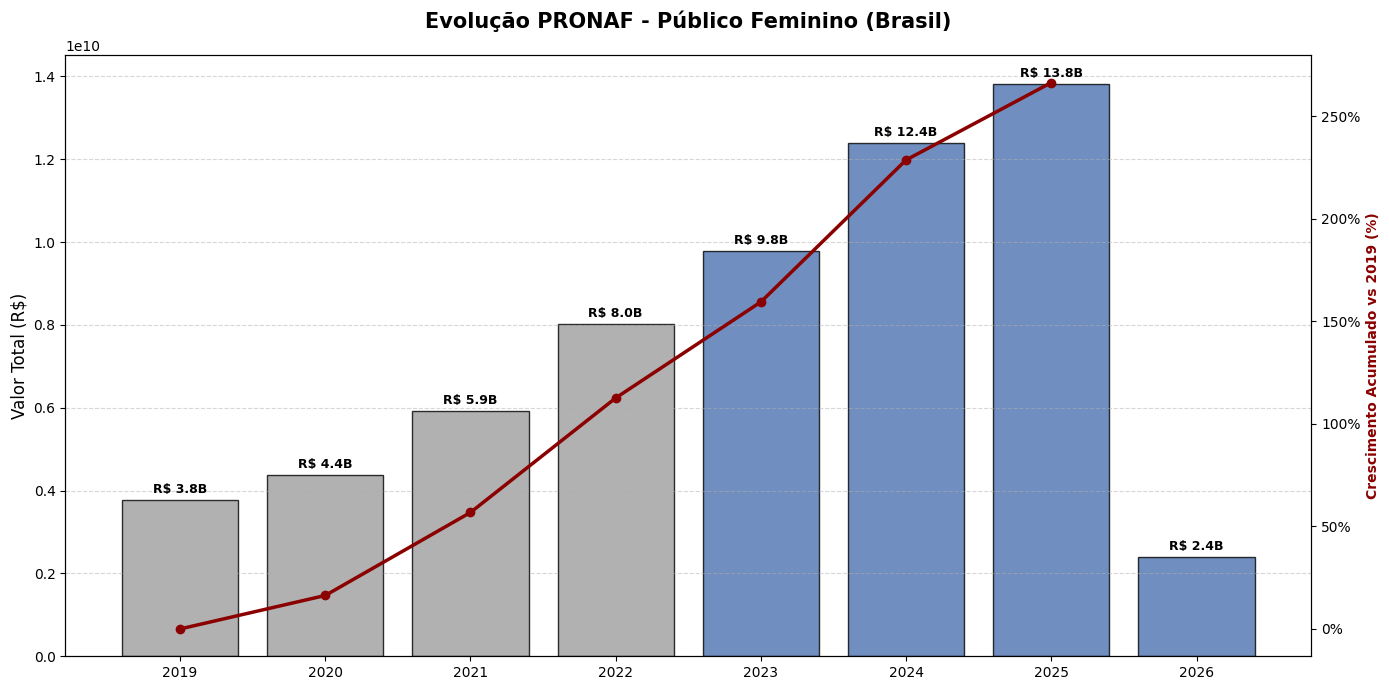


RANKING: 10 Maiores Municípios - Crédito Feminino (2025)


,nome_municipio,uf,valor_total_contratos_anual_Feminino
4407,Sem Informacao,SC,2.149833e+08
4394,Sem Informacao,MG,1.692054e+08
4401,Sem Informacao,PR,1.516106e+08
4406,Sem Informacao,RS,1.449898e+08
4391,Sem Informacao,ES,8.913766e+07
4404,Sem Informacao,RO,8.857876e+07
4397,Sem Informacao,PA,8.303728e+07
2304,Ituporanga,SC,5.715917e+07
81,Alfredo Wagner,SC,5.567523e+07
2054,Imbuia,SC,5.346938e+07


In [ ]:
# 1. Tabela 2026 Feminino
tab_f_26 = df_pronaf_consolidado[df_pronaf_consolidado['ANO_num'] == 2026].groupby('uf')[['valor_total_contratos_anual_Feminino', 'qtd_contratos_anual_Feminino']].sum().reset_index()
print("TABELA: Execução PRONAF Feminino por UF (Março/2026)")
display(tab_f_26.sort_values('valor_total_contratos_anual_Feminino', ascending=False).head(5))

# 2. Gráfico Evolução Feminino
df_ev_f = df_pronaf_consolidado[(df_pronaf_consolidado['ANO_num'] >= 2019) & (df_pronaf_consolidado['ANO_num'] <= 2026)].groupby('ANO_num')['valor_total_contratos_anual_Feminino'].sum().reset_index()
gerar_grafico_secao(df_ev_f, 'valor_total_contratos_anual_Feminino', 'Evolução PRONAF - Público Feminino (Brasil)', 'Valor Total (R$)', None)

# 3. Ranking Municípios Feminino (2025)
rank_f = df_pronaf_consolidado[df_pronaf_consolidado['ANO_num'] == 2025].groupby(['nome_municipio', 'uf'])['valor_total_contratos_anual_Feminino'].sum().reset_index()
print("\nRANKING: 10 Maiores Municípios - Crédito Feminino (2025)")
display(rank_f.sort_values('valor_total_contratos_anual_Feminino', ascending=False).head(10))

## Seção 3: ATER (Assistência Técnica)

TABELA: Famílias com ATER Recebida por UF (2026)


,uf,Soma de familias_com_ater_recebida_no_ano
12,PA,4085
9,MG,1530
22,SP,1311
19,RS,1276
2,AP,714
17,RN,683
20,SC,678
21,SE,648
3,BA,646
7,GO,625


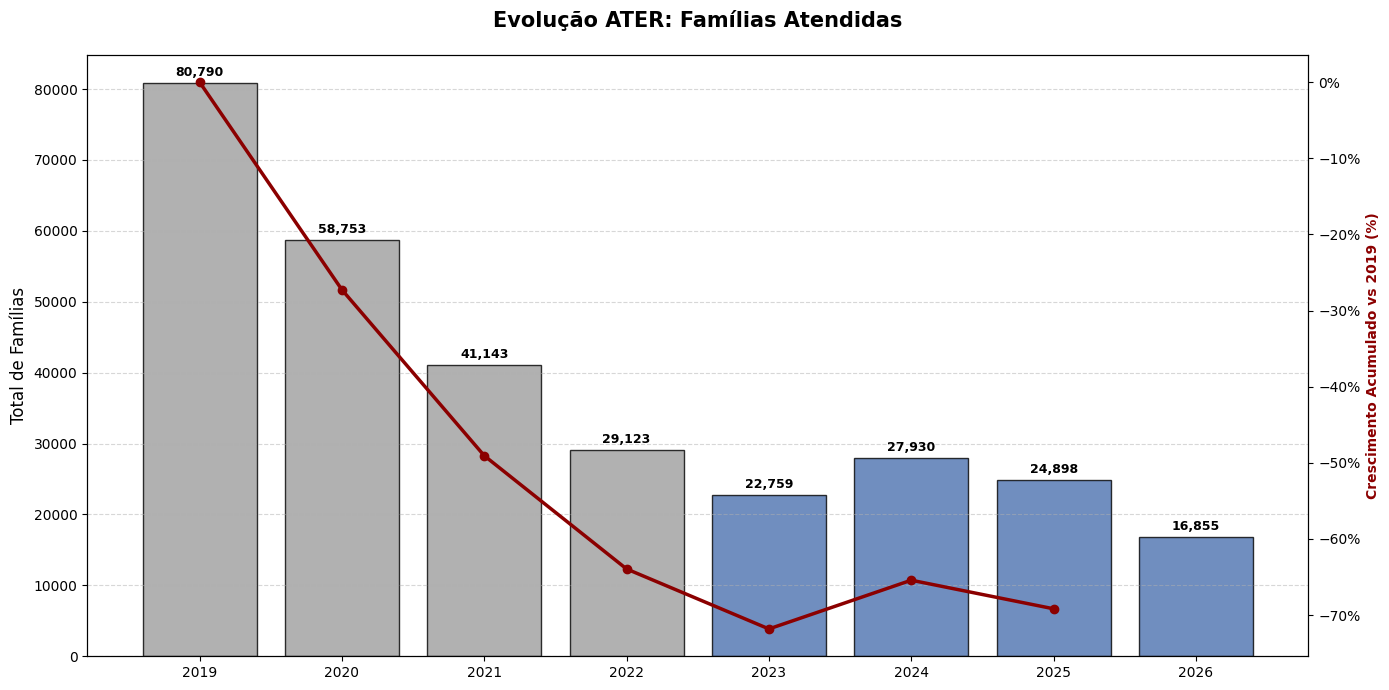


RANKING: 10 Maiores Municípios ATER (2025)


,nome_municipio,uf,Soma de familias_com_ater_recebida_no_ano
49,Belterra,PA,844
453,Tracuateua,PA,750
439,São Sebastião Da Boa Vis,PA,659
33,Augusto Correa,PA,551
152,Flores De Goias,GO,391
59,Brasilia,DF,363
228,João Pinheiro,MG,354
244,Maragogi,AL,329
80,Cansanção,BA,325
233,Laranjal Do Jari,AP,324



COMPARATIVO ATER:
- Triênio 2019-2021: 180,686 famílias
- Triênio 2023-2025: 75,587 famílias
- Variação: -58.17%


In [ ]:
# 1. Tabela 2026 ATER
tab_a_26 = df_ater_consolidado[df_ater_consolidado['ANO_num'] == 2026].groupby('uf')['Soma de familias_com_ater_recebida_no_ano'].sum().reset_index()
print("TABELA: Famílias com ATER Recebida por UF (2026)")
display(tab_a_26.sort_values('Soma de familias_com_ater_recebida_no_ano', ascending=False))

# 2. Gráfico Evolução ATER
df_ev_a = df_ater_consolidado[(df_ater_consolidado['ANO_num'] >= 2019) & (df_ater_consolidado['ANO_num'] <= 2026)].groupby('ANO_num')['Soma de familias_com_ater_recebida_no_ano'].sum().reset_index()
gerar_grafico_secao(df_ev_a, 'Soma de familias_com_ater_recebida_no_ano', 'Evolução ATER: Famílias Atendidas', 'Total de Famílias', None)

# 3. Ranking Municípios ATER (2025)
rank_a = df_ater_consolidado[df_ater_consolidado['ANO_num'] == 2025].groupby(['nome_municipio', 'uf'])['Soma de familias_com_ater_recebida_no_ano'].sum().reset_index()
print("\nRANKING: 10 Maiores Municípios ATER (2025)")
display(rank_a.sort_values('Soma de familias_com_ater_recebida_no_ano', ascending=False).head(10))

# 4. Comparativo Períodos ATER
pa1 = df_ev_a[df_ev_a['ANO_num'].between(2019, 2021)]['Soma de familias_com_ater_recebida_no_ano'].sum()
pa2 = df_ev_a[df_ev_a['ANO_num'].between(2023, 2025)]['Soma de familias_com_ater_recebida_no_ano'].sum()
print(f"\nCOMPARATIVO ATER:\n- Triênio 2019-2021: {int(pa1):,} famílias\n- Triênio 2023-2025: {int(pa2):,} famílias\n- Variação: {(pa2/pa1 - 1)*100:+.2f}%")

# Relatório teste

In [34]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import re
from docx import Document
from docx.shared import Inches, Pt, RGBColor
from docx.enum.text import WD_ALIGN_PARAGRAPH
from google.colab import drive

# --- 1. CONFIGURAÇÃO DE AMBIENTE ---
drive.mount('/content/drive', force_remount=True)
OUTPUT_DIR = '/content/drive/MyDrive/DAMEI_Relatorio_Dados/dados_brutos/saida_teste'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# --- 2. TRATAMENTO E LIMPEZA DE DADOS ---
def padronizar_municipios(df):
    if 'nome_municipio' in df.columns:
        df['nome_municipio'] = df['nome_municipio'].astype(str)
        df['nome_municipio'] = df['nome_municipio'].str.replace(r'-[A-Z]{2}$', '', regex=True).str.title()
    return df

# Aplicando a limpeza
df_pronaf_consolidado = padronizar_municipios(df_pronaf_consolidado)
df_ater_consolidado = padronizar_municipios(df_ater_consolidado)

# --- 3. FUNÇÕES AUXILIARES DE FORMATAÇÃO ---
def format_currency(val):
    return f'R$ {val/1e6:,.1f} Mi'.replace(',', 'X').replace('.', ',').replace('X', '.')

def format_number(val):
    return f'{val:,.0f}'.replace(',', '.')

def format_dynamic(val, col_name):
    if 'valor' in col_name.lower():
        return format_currency(val)
    return format_number(val)

def add_styled_table(doc, df, mapping):
    table = doc.add_table(rows=1, cols=len(mapping))
    table.style = 'Light Grid Accent 1'
    hdr_cells = table.rows[0].cells
    for i, label in enumerate(mapping.values()):
        hdr_cells[i].text = label
    for _, row in df.iterrows():
        row_cells = table.add_row().cells
        for i, col in enumerate(mapping.keys()):
            val = row[col]
            row_cells[i].text = format_dynamic(val, col) if isinstance(val, (int, float)) else str(val)

# --- 4. MOTOR DE GRÁFICOS ---
def create_report_chart(df_ev, col_val, title, filename):
    fig, ax1 = plt.subplots(figsize=(10, 4.5))
    df_ev = df_ev.sort_values('ANO_num')
    anos = df_ev['ANO_num'].astype(str)
    cores = ['#D9D9D9' if int(a) <= 2022 else '#1F4E79' for a in anos]
    ax1.bar(anos, df_ev[col_val], color=cores, alpha=0.9, edgecolor='none')

    if 'valor' in col_val.lower():
        ax1.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f'{x/1e6:,.0f}'))
    else:
        ax1.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f'{x:,.0f}'))

    df_var = df_ev[df_ev['ANO_num'] <= 2025].copy()
    if 2019 in df_var['ANO_num'].values:
        base = df_var.loc[df_var['ANO_num'] == 2019, col_val].values[0]
        if base > 0:
            df_var['pct'] = ((df_var[col_val] / base) - 1) * 100
            ax2 = ax1.twinx()
            ax2.plot(df_var['ANO_num'].astype(str), df_var['pct'], color='#B22222', marker='o', linewidth=2.5)
            ax2.yaxis.set_major_formatter(ticker.PercentFormatter())
            if not df_var.empty:
                last_x, last_y = df_var['ANO_num'].astype(str).iloc[-1], df_var['pct'].iloc[-1]
                ax2.annotate(f'{last_y:+.0f}%', (last_x, last_y), textcoords="offset points", xytext=(0,10), ha='center', color='#B22222', fontsize=11, fontweight='bold')

    ax1.set_title(title, fontsize=13, fontweight='bold', pad=15)
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.savefig(filename, dpi=120, bbox_inches='tight')
    plt.close()

# --- 5. CONSTRUÇÃO DO DOCUMENTO ---
def generate_report(alvo, df_p_full, df_a_full):
    is_br = (alvo == 'BRASIL')
    doc = Document()
    style = doc.styles['Normal']
    style.font.name = 'Arial'
    style.font.size = Pt(11)
    doc.add_heading(f'Relatório de Monitoramento: {alvo}', 0).alignment = WD_ALIGN_PARAGRAPH.CENTER

    df_p = df_p_full if is_br else df_p_full[df_p_full['uf'] == alvo]
    df_a = df_a_full if is_br else df_a_full[df_a_full['uf'] == alvo]

    sections = [
        ('1. PRONAF Geral', 'valor_contratos_total', 'Contratos', 'P'),
        ('2. PRONAF Público-Alvo (Feminino)', 'valor_total_contratos_anual_Feminino', 'Feminino', 'P'),
        ('3. ATER (Assistência Técnica)', 'Soma de familias_com_ater_rece_no_ano', 'ATER', 'A')
    ]

    for title, col, tag, base_type in sections:
        doc.add_heading(title, level=1)
        df_base = df_p if base_type == 'P' else df_a

        # Correção para nomes de colunas parciais
        if col not in df_base.columns:
            matches = [c for c in df_base.columns if tag in c or col[:10] in c]
            col_atual = matches[0] if matches else col
        else:
            col_atual = col

        df_26 = df_base[df_base['ANO_num'] == 2026]
        if not df_26.empty:
            df_v = df_26 if is_br else df_26[~df_26['nome_municipio'].str.contains('Sem Informa', case=False, na=False)]
            summary_26 = df_v.groupby('uf' if is_br else 'nome_municipio')[col_atual].sum().reset_index().sort_values(col_atual, ascending=False).head(3)
            doc.add_paragraph(f'Execução 2026 (Ref. Março) - Top 3:')
            add_styled_table(doc, summary_26, {summary_26.columns[0]: 'Local', col_atual: 'Total'})

        df_ev = df_base.groupby('ANO_num')[col_atual].sum().reset_index()
        chart_name = f'tmp_{tag}_{alvo}.png'
        create_report_chart(df_ev, col_atual, f'Evolução Histórica: {title}', chart_name)
        doc.add_picture(chart_name, width=Inches(5.8))
        if os.path.exists(chart_name):
            os.remove(chart_name)

        t1 = df_ev[df_ev['ANO_num'].between(2019, 2021)][col_atual].sum()
        t2 = df_ev[df_ev['ANO_num'].between(2023, 2025)][col_atual].sum()
        var = ((t2/t1 - 1) * 100) if t1 > 0 else 0
        p = doc.add_paragraph()
        run_insight = p.add_run(f'💡 INSIGHT: Triênio 2023-25 totalizou {format_dynamic(t2, col_atual)} ({var:+.1f}% vs 2019-21).')
        run_insight.bold = True
        doc.add_paragraph()

    doc.save(os.path.join(OUTPUT_DIR, f'Relatorio_Monitoramento_{alvo}.docx'))

# --- 6. EXECUÇÃO DO PIPELINE ---
# Garante que ANO_num existe de forma flexível
for df in [df_pronaf_consolidado, df_ater_consolidado]:
    col_ano = 'ANO' if 'ANO' in df.columns else ('ano' if 'ano' in df.columns else None)
    if col_ano:
        df['ANO_num'] = pd.to_numeric(df[col_ano], errors='coerce')
    elif 'arquivo_origem' in df.columns:
        df['ANO_num'] = df['arquivo_origem'].apply(lambda x: int(re.search(r'(\d{4})', str(x)).group(1)) if re.search(r'(\d{4})', str(x)) else None)

# --- NOVIDADE: FILTRO PARA DESCONSIDERAR ANOS < 2019 ---
df_pronaf_consolidado = df_pronaf_consolidado[df_pronaf_consolidado['ANO_num'] >= 2019].copy()
df_ater_consolidado = df_ater_consolidado[df_ater_consolidado['ANO_num'] >= 2019].copy()
# --------------------------------------------------------

ufs = sorted([u for u in df_pronaf_consolidado['uf'].dropna().unique() if str(u).strip() not in ['nan', '']])
targets = ufs + ['BRASIL']

for alvo in targets:
    generate_report(alvo, df_pronaf_consolidado, df_ater_consolidado)
    print(f"  ✅ {alvo} finalizado.")

print(f"\n⭐ Concluído! Arquivos em: {OUTPUT_DIR}")

Mounted at /content/drive
  ✅ AC finalizado.
  ✅ AL finalizado.
  ✅ AM finalizado.
  ✅ AP finalizado.
  ✅ BA finalizado.
  ✅ CE finalizado.
  ✅ DF finalizado.
  ✅ ES finalizado.
  ✅ GO finalizado.
  ✅ MA finalizado.
  ✅ MG finalizado.
  ✅ MS finalizado.
  ✅ MT finalizado.
  ✅ PA finalizado.
  ✅ PB finalizado.
  ✅ PE finalizado.
  ✅ PI finalizado.
  ✅ PR finalizado.
  ✅ RJ finalizado.
  ✅ RN finalizado.
  ✅ RO finalizado.
  ✅ RR finalizado.
  ✅ RS finalizado.
  ✅ SC finalizado.
  ✅ SE finalizado.
  ✅ SP finalizado.
  ✅ TO finalizado.
  ✅ BRASIL finalizado.

⭐ Concluído! Arquivos em: /content/drive/MyDrive/DAMEI_Relatorio_Dados/dados_brutos/saida_teste
